In [1]:
# format below dictionary to a dataframe
import sys
sys.path.append("/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification")
from src.evaluation.plots import DataLoader, DataProcessor, Plotter





In [2]:
def get_data(cfg):
    data_loader = DataLoader()
    data_processor = DataProcessor()
    data = data_loader.load_data(
            modes=cfg["modes"],
            pos_types=cfg["pos_types"],
            lengths=cfg["prompt_length"],
            trains=cfg["train_splits"],
            evals=cfg["evals"],
            seeds=cfg["seeds"],
            nh_nl=cfg["nh_nl"],
            nalph=cfg["nalph"],
            plot_direct_sbs=cfg["plot_direct_sbs"],
            step_wise_mode=cfg["step_wise_mode"],
            function_type=cfg["function_type"],
            task_max_length_flag=cfg["task_max_length_flag"],
        )

    (train_mean_pts, train_std_pts, test_mean_pts, test_std_pts,
            direct_train_mean_pts, direct_test_mean_pts, 
            direct_train_std_pts, direct_test_std_pts) = data_processor.extract_points(
                data=data,
                modes=cfg["modes"],
                pos_types=cfg["pos_types"],
                lengths=cfg["prompt_length"],
                trains=cfg["train_splits"],
                evals=cfg["evals"],
                seeds=cfg["seeds"],
                self_eval=cfg["self_eval"],
                plot_direct_sbs=cfg["plot_direct_sbs"]
            )
    return train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, direct_train_mean_pts, direct_test_mean_pts, direct_train_std_pts, direct_test_std_pts
    

# Within-K Evaluation

In [2]:
self_eval = True
genral_cfg = {
    "modes": ["direct", "step_by_step"],
    "pos_types": ["abs", "rel_global"],
    "prompt_length": ["fixed"],
    "train_splits": ["combination_2", "combination_3", "combination_4", "combination_5", "combination_6"],
    "evals": ["combination_2", "combination_3", "combination_4", "combination_5", "combination_6"],
    "seeds": [0, 10, 20, 30, 40],
    "plot_direct_sbs": False,
    "function_type": "uniform",
    "task_max_length_flag": "fixed",
    "task_max_length": 7,
    "self_eval": True,
    "step_wise_mode": "individual"
}
genral_cfg["nh_nl"] = "nh12_nl12"

genral_cfg["evals"] = genral_cfg["train_splits"] if genral_cfg["self_eval"] else genral_cfg["eval_splits"]

uniform_without_identity_cfg = genral_cfg.copy()
uniform_without_identity_cfg["function_type"] = "uniform"
uniform_without_identity_cfg["task_max_length"] = 6
uniform_without_identity_cfg["task_max_length_flag"] = "variable"
uniform_without_identity_cfg["nalph"] = f"nalph_26_seqlen_6_fnlen_6_taskmaxlen_6"


# uniform_with_identity_cfg = genral_cfg.copy()
# uniform_with_identity_cfg["function_type"] = "uniform"
# uniform_with_identity_cfg["task_max_length"] = 6
# uniform_with_identity_cfg["task_max_length_flag"] = "variable"
# uniform_with_identity_cfg["nalph"] = f"nalph_26_seqlen_6_fnlen_6_taskmaxlen_7"

diverse_without_identity_cfg = genral_cfg.copy()
diverse_without_identity_cfg["function_type"] = "diverse"
diverse_without_identity_cfg["task_max_length"] = 6
diverse_without_identity_cfg["task_max_length_flag"] = "variable"
diverse_without_identity_cfg["nalph"] = f"nalph_26_seqlen_6_fnlen_6_taskmaxlen_6"


# diverse_with_identity_cfg = genral_cfg.copy()
# diverse_with_identity_cfg["function_type"] = "diverse"
# diverse_with_identity_cfg["task_max_length"] = 7
# diverse_with_identity_cfg["task_max_length_flag"] = "fixed"
# diverse_with_identity_cfg["nalph"] = f"nalph_26_seqlen_6_fnlen_6_taskmaxlen_7"



In [4]:
results = {}
train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(uniform_without_identity_cfg)
results["uniform_without_identity"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}

# train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(uniform_with_identity_cfg)
# results["uniform_with_identity"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}

train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(diverse_without_identity_cfg)
results["diverse_without_identity"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}

# train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(diverse_with_identity_cfg)
# results["diverse_with_identity"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}






['direct', 'step_by_step'] ['abs', 'rel_global'] ['fixed'] ['combination_2', 'combination_3', 'combination_4', 'combination_5', 'combination_6'] ['combination_2', 'combination_3', 'combination_4', 'combination_5', 'combination_6'] [0, 10, 20, 30, 40]
/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/models/eval/uniform/nalph_26_seqlen_6_fnlen_6_taskmaxlen_2/direct/fixed/model_combination_2/eval_combination_2/abs/nh12_nl12/seed_0/accs.pkl
direct abs fixed combination_2 combination_2 0
0.0
Path /project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/models/eval/uniform/nalph_26_seqlen_6_fnlen_6_taskmaxlen_2/direct/fixed/model_combination_2/eval_combination_2/abs/nh12_nl12/seed_10/accs.pkl does not exist
Path /project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/models/eval/uniform/nalph_26_seqlen_6_fnlen_6_taskmaxlen_2/direct/fixed/model_combination_2/eval_combination_2/abs/nh12_nl12/seed_20/accs.pkl does not exist
Path /project/pi_jensen_um

In [5]:
results["uniform_without_identity"]["train_mean_pts"]["direct"]["abs"]["fixed"]

[np.float32(1.0),
 np.float32(1.0),
 np.float32(1.0),
 np.float32(1.0),
 np.float32(1.0)]

In [5]:
# results_without_uniform = {'direct': {'abs': {'fixed': [0.0, 0.0, 0.0, 0.0, 0.0]}, 'rel_global': {'fixed': [0.0, 0.0, 0.0, 0.0, 0.0]}}, 'step_by_step': {'abs': {'fixed': [0.9969987869262695, 0.9998998641967773, 0.998389720916748, 0.9998993873596191, 0.999597430229187]}, 'rel_global': {'fixed': [0.9920968413352966, 0.9997996687889099, 0.996477484703064, 1.0, 0.9958736300468445]}}}
# results_with_uniform = {'direct': {'abs': {'fixed': [0.999497652053833, 0.9964286088943481, 0.9998677372932434, 0.9971340298652649, 0.9715608358383179]}, 'rel_global': {'fixed': [0.9974884390830994, 0.9953463673591614, 0.9989418387413025, 0.9992283582687378, 0.983796238899231]}}, 'step_by_step': {'abs': {'fixed': [0.9992967247962952, 0.9996753334999084, 0.9998677372932434, 0.9997795224189758, 0.999448835849762]}, 'rel_global': {'fixed': [0.9998995065689087, 0.9998918175697327, 0.9996032118797302, 0.9997795224189758, 0.9997795224189758]}}}
# results_with_diverse = {'direct': {'abs': {'fixed': [0.9505726099014282, 0.9334415793418884, 0.9136243462562561, 0.9071869254112244, 0.925595223903656]}, 'rel_global': {'fixed': [0.9484629034996033, 0.8705627918243408, 0.8687830567359924, 0.8934082388877869, 0.9184303283691406]}}, 'step_by_step': {'abs': {'fixed': [0.9355033040046692, 0.9587662816047668, 0.9542328119277954, 0.9679232239723206, 0.9783950448036194]}, 'rel_global': {'fixed': [0.963934063911438, 0.9622294902801514, 0.946825385093689, 0.9444444179534912, 0.9420193433761597]}}}
# results_without_diverse = {'direct': {'abs': {'fixed': [0.3617447018623352, 0.529146671295166, 0.8052536249160767, 0.8573873043060303, 0.8729871511459351]}, 'rel_global': {'fixed': [0.25120046734809875, 0.5062099695205688, 0.7791867852210999, 0.8393719792366028, 0.8584944009780884]}}, 'step_by_step': {'abs': {'fixed': [0.46528610587120056, 0.9043469429016113, 0.960044264793396, 0.9628623127937317, 0.9632648825645447]}, 'rel_global': {'fixed': [0.45878350734710693, 0.9609375, 0.9410225749015808, 0.9425322413444519, 0.9342793822288513]}}}
import numpy as np
mean_results_without_uniform = results["uniform_without_identity"]["test_mean_pts"]
# mean_results_with_uniform = results["uniform_with_identity"]["test_mean_pts"] 
# mean_results_with_diverse = results["diverse_with_identity"]["test_mean_pts"]
mean_results_without_diverse = results["diverse_without_identity"]["test_mean_pts"]

std_results_without_uniform = results["uniform_without_identity"]["test_std_pts"]
# std_results_with_uniform = results["uniform_with_identity"]["test_std_pts"]
# std_results_with_diverse = results["diverse_with_identity"]["test_std_pts"]
std_results_without_diverse = results["diverse_without_identity"]["test_std_pts"]


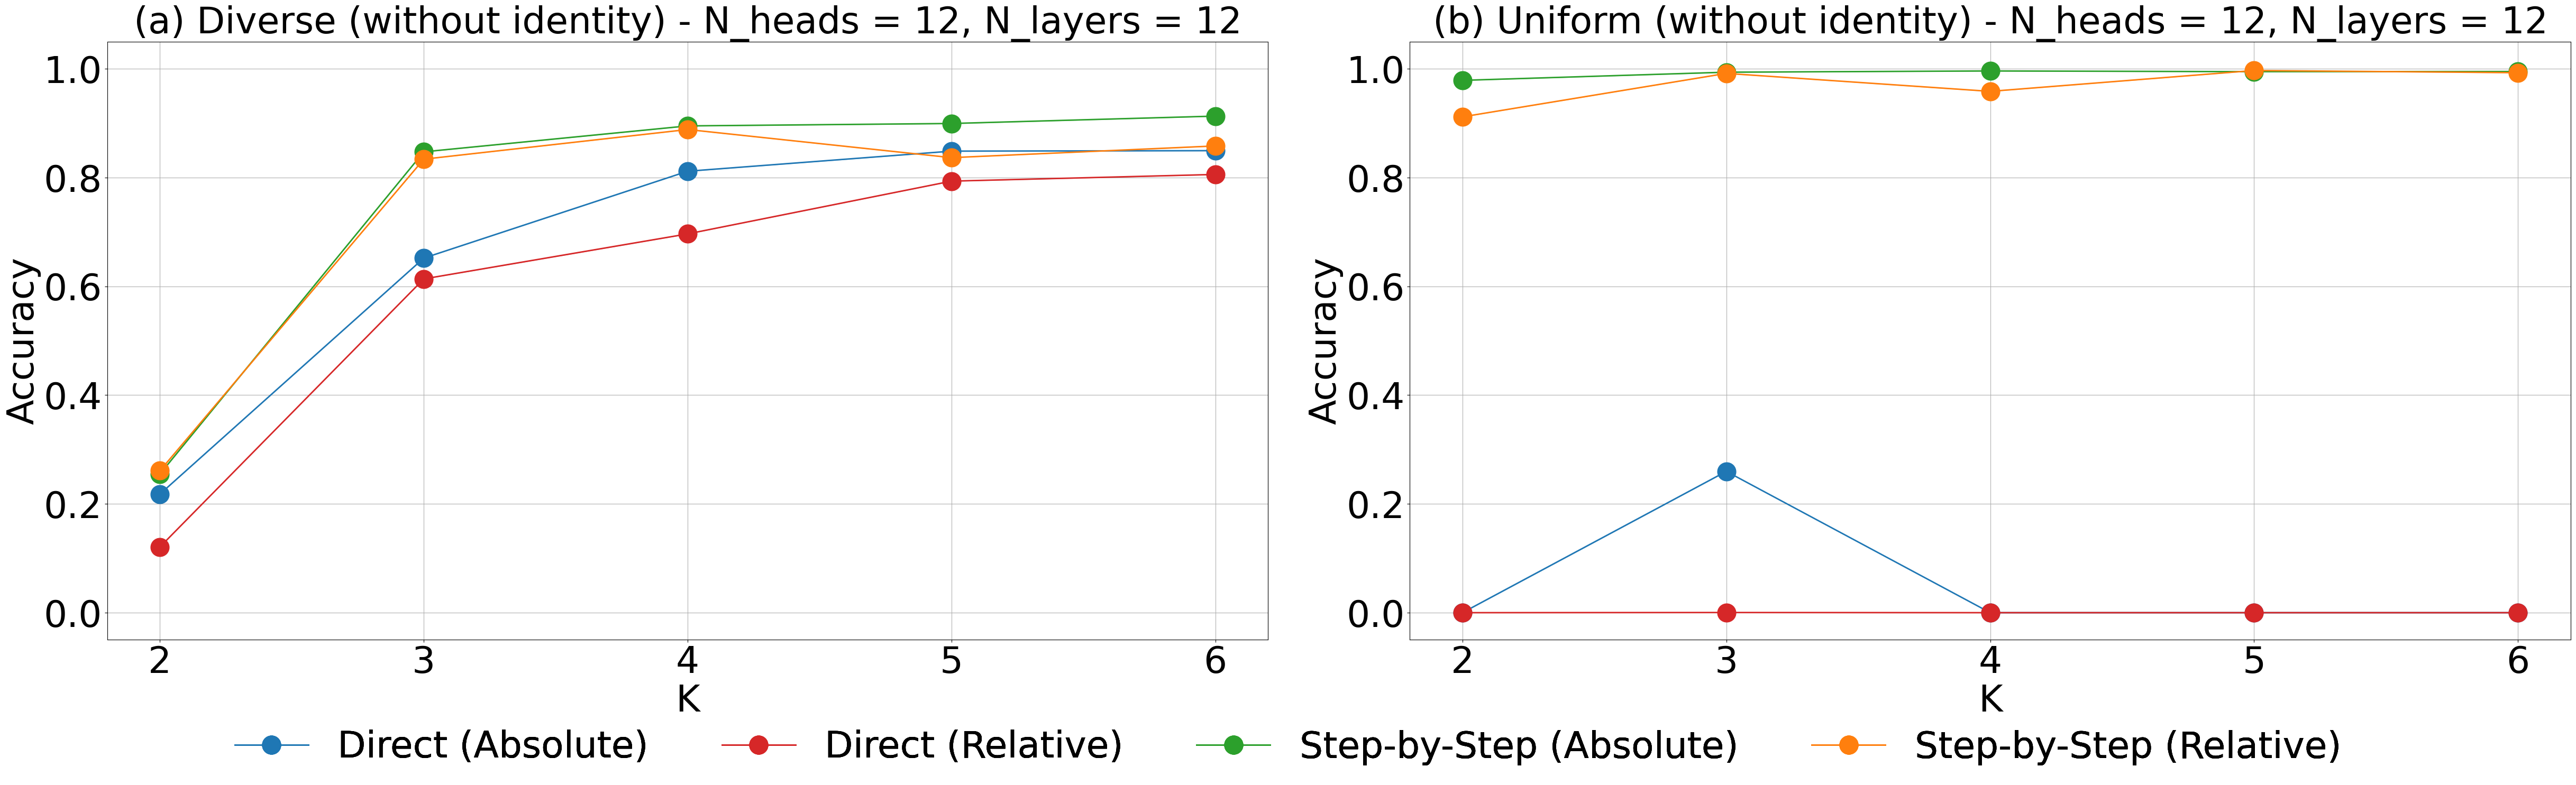

In [6]:
from matplotlib import pyplot as plt

font_size = 50
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})

# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
X = [2, 3, 4, 5, 6]
# have four subfigures with two plots each
colors = {
        "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
        "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
        "step_by_step_direct_fixed": {"abs": "tab:purple", "rel_global": "tab:brown"},
        "direct_variable": {"abs": "tab:cyan", "rel_global": "tab:pink"},
        "step_by_step_variable": {"abs": "tab:olive", "rel_global": "tab:gray"},
        "step_by_step_direct_variable": {"abs": "tab:gray", "rel_global": "tab:olive"},
    }

fig, axs = plt.subplots(1, 2, figsize=(50, 15))

# for j, mode in enumerate(modes):
#     for k, pos in enumerate(pos_types):
#         color = colors[mode + "_" + length][pos]
#         pos_label = "Relative" if pos == "rel_global" else "Absolute"
#         mode_label = "Direct" if mode == "direct" else "Step-by-Step"
#         axs[0].plot(X,mean_results_with_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2, label=f"{mode_label} ({pos_label})")
#         axs[0].fill_between(X, np.array(mean_results_with_diverse[mode][pos]["fixed"]) - np.array(std_results_with_diverse[mode][pos]["fixed"]), np.array(mean_results_with_diverse[mode][pos]["fixed"]) + np.array(std_results_with_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)      
#         # have title below the plot
#         axs[0].set_title(f"(a) Diverse (with identity)", fontsize=font_size)

for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        color = colors[mode + "_" + length][pos]
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[0].plot(X,mean_results_without_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2, label=f"{mode_label} ({pos_label})")
        axs[0].fill_between(X, np.array(mean_results_without_diverse[mode][pos]["fixed"]) - np.array(std_results_without_diverse[mode][pos]["fixed"]), np.array(mean_results_without_diverse[mode][pos]["fixed"]) + np.array(std_results_without_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[0].set_title(f"(a) Diverse (without identity) - N_heads = 12, N_layers = 12", fontsize=font_size)

# for j, mode in enumerate(modes):
#     for k, pos in enumerate(pos_types):
#         color = colors[mode + "_" + length][pos]
#         pos_label = "Relative" if pos == "rel_global" else "Absolute"
#         mode_label = "Direct" if mode == "direct" else "Step-by-Step"
#         axs[2].plot(X,mean_results_with_uniform[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
#         axs[2].fill_between(X, np.array(mean_results_with_uniform[mode][pos]["fixed"]) - np.array(std_results_with_uniform[mode][pos]["fixed"]), np.array(mean_results_with_uniform[mode][pos]["fixed"]) + np.array(std_results_with_uniform[mode][pos]["fixed"]), alpha=0.2, color=color)
#         axs[2].set_title(f"(c) Uniform (with identity)", fontsize=font_size)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        color = colors[mode + "_" + length][pos]
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[1].plot(X,mean_results_without_uniform[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[1].fill_between(X, np.array(mean_results_without_uniform[mode][pos]["fixed"]) - np.array(std_results_without_uniform[mode][pos]["fixed"]), np.array(mean_results_without_uniform[mode][pos]["fixed"]) + np.array(std_results_without_uniform[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[1].set_title(f"(b) Uniform (without identity) - N_heads = 12, N_layers = 12", fontsize=font_size)
        # set y-axis limit between 0 and 1
        axs[0].set_ylim(-0.05, 1.05)
        axs[1].set_ylim(-0.05, 1.05)
        # axs[2].set_ylim(-0.05, 1.05)
        # axs[3].set_ylim(-0.05, 1.05)
        # # have x-axis label as Combination Size (K)
        axs[0].set_xlabel("K", fontsize=font_size)
        axs[1].set_xlabel("K", fontsize=font_size)
        # axs[2].set_xlabel("K", fontsize=font_size)
        # axs[3].set_xlabel("K", fontsize=font_size)

        # have y-axis label as Accuracy
        axs[0].set_ylabel("Accuracy", fontsize=font_size)
        axs[1].set_ylabel("Accuracy", fontsize=font_size)
        # axs[2].set_ylabel("Accuracy", fontsize=font_size)
        # axs[3].set_ylabel("Accuracy", fontsize=font_size)

        # have legend below the four plots
        handles, labels = axs[0].get_legend_handles_labels()
        # include grid lines
        axs[0].grid(True)
        axs[1].grid(True)
        # axs[2].grid(True)
        # axs[3].grid(True)
        fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=font_size, bbox_to_anchor=(0.5, -0.05), frameon=False)
        # have x-axis as 2,3,4,5
        axs[0].set_xticks([2, 3, 4, 5, 6])
        axs[1].set_xticks([2, 3, 4, 5, 6])
        # axs[2].set_xticks([2, 3, 4, 5, 6])
        # axs[3].set_xticks([2, 3, 4, 5, 6])
        

# save the figure
# tight layout
plt.tight_layout()
# plt.show()
plt.savefig("within_k_evaluation_nh12_nl12.pdf", dpi=300, bbox_inches='tight')




















# Cross K Evaluation

In [ ]:
self_eval = False
genral_cfg = {
    "modes": ["direct", "step_by_step"],
    "pos_types": ["abs", "rel_global"],
    "prompt_length": ["fixed"],
    "train_splits": ["combination_3"],
    "eval_splits": ["combination_1", "combination_2", "combination_3", "combination_4", "combination_5", "combination_6"],
    "seeds": [0, 10, 20, 30, 40],
    "plot_direct_sbs": False,
    "function_type": "uniform",
    "task_max_length_flag": "fixed",
    "task_max_length": 7,
    "self_eval": False,
    "step_wise_mode": "individual"
}
genral_cfg["nh_nl"] = "nh6_nl3"
genral_cfg["nalph"] = f"nalph_26_seqlen_6_fnlen_6_taskmaxlen_7"
genral_cfg["evals"] = genral_cfg["train_splits"] if genral_cfg["self_eval"] else genral_cfg["eval_splits"]

train_6_diverse_results_cfg = genral_cfg.copy()
train_6_diverse_results_cfg["function_type"] = "diverse"
train_6_diverse_results_cfg["train_splits"] = ["combination_6"]

train_3_diverse_results_cfg = genral_cfg.copy()
train_3_diverse_results_cfg["function_type"] = "diverse"
train_3_diverse_results_cfg["train_splits"] = ["combination_3"]

train_6_uniform_results_cfg = genral_cfg.copy()
train_6_uniform_results_cfg["function_type"] = "uniform"
train_6_uniform_results_cfg["train_splits"] = ["combination_6"]

train_3_uniform_results_cfg = genral_cfg.copy()
train_3_uniform_results_cfg["function_type"] = "uniform"
train_3_uniform_results_cfg["train_splits"] = ["combination_3"]



In [ ]:
results = {}
train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_6_diverse_results_cfg)
results["train_6_diverse"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}

train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_6_uniform_results_cfg)
results["train_6_uniform"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}

train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_3_diverse_results_cfg)
results["train_3_diverse"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}

train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_3_uniform_results_cfg)
results["train_3_uniform"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}






In [ ]:
# import pickle
# with open("/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/models/eval/diverse/nalph_26_seqlen_6_fnlen_6_taskmaxlen_7/direct/fixed/model_combination_6/eval_combination_1/abs/nh6_nl3/seed_0/accs.pkl", "rb") as f:
#     results = pickle.load(f)


In [ ]:
# ckpt, r = results[0]
# r.keys()

In [ ]:
# results_without_uniform = {'direct': {'abs': {'fixed': [0.0, 0.0, 0.0, 0.0, 0.0]}, 'rel_global': {'fixed': [0.0, 0.0, 0.0, 0.0, 0.0]}}, 'step_by_step': {'abs': {'fixed': [0.9969987869262695, 0.9998998641967773, 0.998389720916748, 0.9998993873596191, 0.999597430229187]}, 'rel_global': {'fixed': [0.9920968413352966, 0.9997996687889099, 0.996477484703064, 1.0, 0.9958736300468445]}}}
# results_with_uniform = {'direct': {'abs': {'fixed': [0.999497652053833, 0.9964286088943481, 0.9998677372932434, 0.9971340298652649, 0.9715608358383179]}, 'rel_global': {'fixed': [0.9974884390830994, 0.9953463673591614, 0.9989418387413025, 0.9992283582687378, 0.983796238899231]}}, 'step_by_step': {'abs': {'fixed': [0.9992967247962952, 0.9996753334999084, 0.9998677372932434, 0.9997795224189758, 0.999448835849762]}, 'rel_global': {'fixed': [0.9998995065689087, 0.9998918175697327, 0.9996032118797302, 0.9997795224189758, 0.9997795224189758]}}}
# results_with_diverse = {'direct': {'abs': {'fixed': [0.9505726099014282, 0.9334415793418884, 0.9136243462562561, 0.9071869254112244, 0.925595223903656]}, 'rel_global': {'fixed': [0.9484629034996033, 0.8705627918243408, 0.8687830567359924, 0.8934082388877869, 0.9184303283691406]}}, 'step_by_step': {'abs': {'fixed': [0.9355033040046692, 0.9587662816047668, 0.9542328119277954, 0.9679232239723206, 0.9783950448036194]}, 'rel_global': {'fixed': [0.963934063911438, 0.9622294902801514, 0.946825385093689, 0.9444444179534912, 0.9420193433761597]}}}
# results_without_diverse = {'direct': {'abs': {'fixed': [0.3617447018623352, 0.529146671295166, 0.8052536249160767, 0.8573873043060303, 0.8729871511459351]}, 'rel_global': {'fixed': [0.25120046734809875, 0.5062099695205688, 0.7791867852210999, 0.8393719792366028, 0.8584944009780884]}}, 'step_by_step': {'abs': {'fixed': [0.46528610587120056, 0.9043469429016113, 0.960044264793396, 0.9628623127937317, 0.9632648825645447]}, 'rel_global': {'fixed': [0.45878350734710693, 0.9609375, 0.9410225749015808, 0.9425322413444519, 0.9342793822288513]}}}
split = "test"
import numpy as np
mean_train_6_diverse = results["train_6_diverse"][f"{split}_mean_pts"]
mean_train_6_uniform = results["train_6_uniform"][f"{split}_mean_pts"] 
mean_train_3_diverse = results["train_3_diverse"][f"{split}_mean_pts"]
mean_train_3_uniform = results["train_3_uniform"][f"{split}_mean_pts"]

std_train_6_diverse = results["train_6_diverse"][f"{split}_std_pts"]
std_train_6_uniform = results["train_6_uniform"][f"{split}_std_pts"]
std_train_3_diverse = results["train_3_diverse"][f"{split}_std_pts"]
std_train_3_uniform = results["train_3_uniform"][f"{split}_std_pts"]


In [ ]:
# train_6_diverse_results = {'direct': {'abs': {'fixed': [0.009400940500199795, 0.01778179593384266, 0.039177488535642624, 0.09047619253396988, 0.25749558210372925, 0.925595223903656]}, 'rel_global': {'fixed': [0.00030002999119460583, 0.008438818156719208, 0.04978355020284653, 0.13650794327259064, 0.34656083583831787, 0.9184303283691406]}}, 'step_by_step': {'abs': {'fixed': [0.11071107536554337, 0.3944143056869507, 0.6362554430961609, 0.8462963104248047, 0.9565696120262146, 0.9783950448036194]}, 'rel_global': {'fixed': [0.431343138217926, 0.7070524096488953, 0.81699138879776, 0.8842592835426331, 0.9187610149383545, 0.9420193433761597]}}}
# train_3_diverse_results = {'direct': {'abs': {'fixed': [0.16941694915294647, 0.7481414079666138, 0.9334415793418884, 0.5329365134239197, 0.16545413434505463, 0.011794532649219036]}, 'rel_global': {'fixed': [0.006500650197267532, 0.6120152473449707, 0.8705627918243408, 0.5830687880516052, 0.30335095524787903, 0.16942238807678223]}}, 'step_by_step': {'abs': {'fixed': [0.706770658493042, 0.9559975862503052, 0.9587662816047668, 0.8699735403060913, 0.5890652537345886, 0.11651234328746796]}, 'rel_global': {'fixed': [0.9762976169586182, 0.981615424156189, 0.9622294902801514, 0.9058201313018799, 0.7906745672225952, 0.5767195820808411]}}}
# train_6_uniform_results = {'direct': {'abs': {'fixed': [0.0, 0.0, 0.0, 0.0, 0.0, 0.9715608358383179]}, 'rel_global': {'fixed': [0.0, 0.0, 0.0, 0.0, 0.0, 0.983796238899231]}}, 'step_by_step': {'abs': {'fixed': [0.0, 0.0, 0.0, 0.027248676866292953, 0.7147266268730164, 0.999448835849762]}, 'rel_global': {'fixed': [0.2491249144077301, 0.5901145339012146, 0.8803030252456665, 0.9878306984901428, 0.9990078806877136, 0.9997795224189758]}}}
# train_3_uniform_results = {'direct': {'abs': {'fixed': [0.0, 0.0, 0.9964286088943481, 0.0, 0.0, 0.0]}, 'rel_global': {'fixed': [0.0, 0.0, 0.9953463673591614, 0.0, 0.0, 0.0]}}, 'step_by_step': {'abs': {'fixed': [0.8052805066108704, 0.990556538105011, 0.9996753334999084, 0.9523809552192688, 0.23070986568927765, 0.0]}, 'rel_global': {'fixed': [0.9997999668121338, 0.9999999403953552, 0.9998918175697327, 0.9996032118797302, 0.9929453134536743, 0.7336860299110413]}}}



In [ ]:
# plot line plot for with and without identity results side by side four plots with legend below 
from matplotlib import pyplot as plt

font_size = 50
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})

function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
X = [1, 2, 3, 4, 5, 6]
fig, axs = plt.subplots(1, 4, figsize=(50, 15))
# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
# have four subfigures with two plots each
colors = {
        "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
        "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
    }

for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[0].plot(X,mean_train_6_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2, label=f"{mode_label} ({pos_label})")
        axs[0].fill_between(X, np.array(mean_train_6_diverse[mode][pos]["fixed"]) - np.array(std_train_6_diverse[mode][pos]["fixed"]), np.array(mean_train_6_diverse[mode][pos]["fixed"]) + np.array(std_train_6_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        # have title below the plot
        axs[0].set_title(f"(a) Diverse (Train K=6)", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[2].plot(X,mean_train_6_uniform[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[2].fill_between(X, np.array(mean_train_6_uniform[mode][pos]["fixed"]) - np.array(std_train_6_uniform[mode][pos]["fixed"]), np.array(mean_train_6_uniform[mode][pos]["fixed"]) + np.array(std_train_6_uniform[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[2].set_title(f"(b) Uniform (Train K=6)", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[1].plot(X,mean_train_3_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[1].fill_between(X, np.array(mean_train_3_diverse[mode][pos]["fixed"]) - np.array(std_train_3_diverse[mode][pos]["fixed"]), np.array(mean_train_3_diverse[mode][pos]["fixed"]) + np.array(std_train_3_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[1].set_title(f"(c) Diverse (Train K=3)", fontsize=font_size)
print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        print(mode, pos, print(len(mean_train_3_uniform[mode][pos]["fixed"])))
        axs[3].plot(X,mean_train_3_uniform[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[3].fill_between(X, np.array(mean_train_3_uniform[mode][pos]["fixed"]) - np.array(std_train_3_uniform[mode][pos]["fixed"]), np.array(mean_train_3_uniform[mode][pos]["fixed"]) + np.array(std_train_3_uniform[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[3].set_title(f"(d) Uniform (Train K=3)", fontsize=font_size)
    # set y-axis limit between 0 and 1
    axs[0].set_ylim(-0.05, 1.05)
    axs[1].set_ylim(-0.05, 1.05)
    axs[2].set_ylim(-0.05, 1.05)
    axs[3].set_ylim(-0.05, 1.05)
    # have x-axis label as Combination Size (K)
    axs[0].set_xlabel("Evaluation K", fontsize=font_size)
    axs[1].set_xlabel("Evaluation K", fontsize=font_size)
    axs[2].set_xlabel("Evaluation K", fontsize=font_size)
    axs[3].set_xlabel("Evaluation K", fontsize=font_size)

    # have y-axis label as Accuracy
    axs[0].set_ylabel("Accuracy", fontsize=font_size)
    axs[1].set_ylabel("Accuracy", fontsize=font_size)
    axs[2].set_ylabel("Accuracy", fontsize=font_size)
    axs[3].set_ylabel("Accuracy", fontsize=font_size)

    # have legend below the four plots
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=font_size, bbox_to_anchor=(0.5, -0.05), frameon=False)
    # have x-axis as 2,3,4,5
    axs[0].set_xticks([1, 2, 3, 4, 5, 6])
    axs[1].set_xticks([1, 2, 3, 4, 5, 6])
    axs[2].set_xticks([1, 2, 3, 4, 5, 6])
    axs[3].set_xticks([1, 2, 3, 4, 5, 6])
    # have grid lines
    axs[0].grid(True)
    axs[1].grid(True)
    axs[2].grid(True)
    axs[3].grid(True)

# have leg
        

# Save figure with legend below the plots, ensuring legend is included in the saved file
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.savefig("cross_K_evaluation.pdf", dpi=300, bbox_inches='tight')







# All cross K evaluation results

In [ ]:
# All cross K evaluation results

self_eval = False
genral_cfg = {
    "modes": ["direct", "step_by_step"],
    "pos_types": ["abs", "rel_global"],
    "prompt_length": ["fixed"],
    "train_splits": ["combination_3"],
    "eval_splits": ["combination_1", "combination_2", "combination_3", "combination_4", "combination_5", "combination_6"],
    "seeds": [0, 10, 20, 30, 40],
    "plot_direct_sbs": False,
    "function_type": "uniform",
    "task_max_length_flag": "fixed",
    "task_max_length": 7,
    "self_eval": False,
    "step_wise_mode": "individual"
}
genral_cfg["nh_nl"] = "nh6_nl3"
genral_cfg["nalph"] = f"nalph_26_seqlen_6_fnlen_6_taskmaxlen_7"
genral_cfg["evals"] = genral_cfg["train_splits"] if genral_cfg["self_eval"] else genral_cfg["eval_splits"]

train_1_diverse_results_cfg = genral_cfg.copy()
train_1_diverse_results_cfg["function_type"] = "diverse"
train_1_diverse_results_cfg["train_splits"] = ["combination_1"]

train_2_diverse_results_cfg = genral_cfg.copy()
train_2_diverse_results_cfg["function_type"] = "diverse"
train_2_diverse_results_cfg["train_splits"] = ["combination_2"]

train_3_diverse_results_cfg = genral_cfg.copy()
train_3_diverse_results_cfg["function_type"] = "diverse"
train_3_diverse_results_cfg["train_splits"] = ["combination_3"]

train_4_diverse_results_cfg = genral_cfg.copy()
train_4_diverse_results_cfg["function_type"] = "diverse"
train_4_diverse_results_cfg["train_splits"] = ["combination_4"]

train_5_diverse_results_cfg = genral_cfg.copy()
train_5_diverse_results_cfg["function_type"] = "diverse"
train_5_diverse_results_cfg["train_splits"] = ["combination_5"]

train_6_diverse_results_cfg = genral_cfg.copy()
train_6_diverse_results_cfg["function_type"] = "diverse"
train_6_diverse_results_cfg["train_splits"] = ["combination_6"]


In [ ]:
results = {}
train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_1_diverse_results_cfg)
results["train_1_diverse"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}

train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_2_diverse_results_cfg)
results["train_2_diverse"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}   


train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_3_diverse_results_cfg)
results["train_3_diverse"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}

train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_4_diverse_results_cfg)
results["train_4_diverse"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}

train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_5_diverse_results_cfg)
results["train_5_diverse"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}

train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_6_diverse_results_cfg)
results["train_6_diverse"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}



In [ ]:
split = "test"
import numpy as np
mean_train_1_diverse = results["train_1_diverse"][f"{split}_mean_pts"]
mean_train_2_diverse = results["train_2_diverse"][f"{split}_mean_pts"]
mean_train_3_diverse = results["train_3_diverse"][f"{split}_mean_pts"]
mean_train_4_diverse = results["train_4_diverse"][f"{split}_mean_pts"]
mean_train_5_diverse = results["train_5_diverse"][f"{split}_mean_pts"]
mean_train_6_diverse = results["train_6_diverse"][f"{split}_mean_pts"]

std_train_1_diverse = results["train_1_diverse"][f"{split}_std_pts"]
std_train_2_diverse = results["train_2_diverse"][f"{split}_std_pts"]
std_train_3_diverse = results["train_3_diverse"][f"{split}_std_pts"]
std_train_4_diverse = results["train_4_diverse"][f"{split}_std_pts"]
std_train_5_diverse = results["train_5_diverse"][f"{split}_std_pts"]
std_train_6_diverse = results["train_6_diverse"][f"{split}_std_pts"]


In [ ]:
# have two plots with 3 figures each


from matplotlib import pyplot as plt

font_size = 50
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})

function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
X = [1, 2, 3, 4, 5, 6]
fig, axs = plt.subplots(1, 3, figsize=(50, 15))
# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
# have four subfigures with two plots each
colors = {
        "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
        "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
    }

for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[0].plot(X,mean_train_1_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2, label=f"{mode_label} ({pos_label})")
        axs[0].fill_between(X, np.array(mean_train_1_diverse[mode][pos]["fixed"]) - np.array(std_train_1_diverse[mode][pos]["fixed"]), np.array(mean_train_1_diverse[mode][pos]["fixed"]) + np.array(std_train_1_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        # have title below the plot
        axs[0].set_title(f"(a) Diverse (Train K=1)", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[1].plot(X,mean_train_2_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[1].fill_between(X, np.array(mean_train_2_diverse[mode][pos]["fixed"]) - np.array(std_train_2_diverse[mode][pos]["fixed"]), np.array(mean_train_2_diverse[mode][pos]["fixed"]) + np.array(std_train_2_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[1].set_title(f"(b) Diverse (Train K=2)", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[2].plot(X,mean_train_3_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[2].fill_between(X, np.array(mean_train_3_diverse[mode][pos]["fixed"]) - np.array(std_train_3_diverse[mode][pos]["fixed"]), np.array(mean_train_3_diverse[mode][pos]["fixed"]) + np.array(std_train_3_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[2].set_title(f"(c) Diverse (Train K=3)", fontsize=font_size)
print(colors)
# for j, mode in enumerate(modes):
#     for k, pos in enumerate(pos_types):
#         print(mode, pos)
#         color = colors[mode + "_" + length][pos]
#         print(color)
#         pos_label = "Relative" if pos == "rel_global" else "Absolute"
#         mode_label = "Direct" if mode == "direct" else "Step-by-Step"
#         print(mode, pos, print(len(mean_train_3_uniform[mode][pos]["fixed"])))
#         axs[3].plot(X,mean_train_3_uniform[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
#         axs[3].fill_between(X, np.array(mean_train_3_uniform[mode][pos]["fixed"]) - np.array(std_train_3_uniform[mode][pos]["fixed"]), np.array(mean_train_3_uniform[mode][pos]["fixed"]) + np.array(std_train_3_uniform[mode][pos]["fixed"]), alpha=0.2, color=color)
#         axs[3].set_title(f"(d) Diverse (Train K=4)", fontsize=font_size)
    # set y-axis limit between 0 and 1
axs[0].set_ylim(-0.05, 1.05)
axs[1].set_ylim(-0.05, 1.05)
axs[2].set_ylim(-0.05, 1.05)
# axs[3].set_ylim(-0.05, 1.05)
# have x-axis label as Combination Size (K)
axs[0].set_xlabel("Evaluation K", fontsize=font_size)
axs[1].set_xlabel("Evaluation K", fontsize=font_size)
axs[2].set_xlabel("Evaluation K", fontsize=font_size)
# axs[3].set_xlabel("Evaluation K", fontsize=font_size)

# have y-axis label as Accuracy
axs[0].set_ylabel("Accuracy", fontsize=font_size)
axs[1].set_ylabel("Accuracy", fontsize=font_size)
axs[2].set_ylabel("Accuracy", fontsize=font_size)
# axs[3].set_ylabel("Accuracy", fontsize=font_size)

# have legend below the four plots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=font_size, bbox_to_anchor=(0.5, -0.05), frameon=False)
# have x-axis as 2,3,4,5
axs[0].set_xticks([1, 2, 3, 4, 5, 6])
axs[1].set_xticks([1, 2, 3, 4, 5, 6])
axs[2].set_xticks([1, 2, 3, 4, 5, 6])
# axs[3].set_xticks([1, 2, 3, 4, 5, 6])
# have grid lines
axs[0].grid(True)
axs[1].grid(True)
axs[2].grid(True)
    # axs[3].grid(True)

# have leg
        

# Save figure with legend below the plots, ensuring legend is included in the saved file
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.savefig("cross_K_evaluation_diverse_1_3.pdf", dpi=300, bbox_inches='tight')


# have two plots with 3 figures each


from matplotlib import pyplot as plt

font_size = 50
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})

function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
X = [1, 2, 3, 4, 5, 6]
fig, axs = plt.subplots(1, 3, figsize=(50, 15))
# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
# have four subfigures with two plots each
colors = {
        "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
        "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
    }

for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[0].plot(X,mean_train_4_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2, label=f"{mode_label} ({pos_label})")
        axs[0].fill_between(X, np.array(mean_train_4_diverse[mode][pos]["fixed"]) - np.array(std_train_4_diverse[mode][pos]["fixed"]), np.array(mean_train_4_diverse[mode][pos]["fixed"]) + np.array(std_train_4_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        # have title below the plot
        axs[0].set_title(f"(a) Diverse (Train K=4)", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[1].plot(X,mean_train_5_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[1].fill_between(X, np.array(mean_train_5_diverse[mode][pos]["fixed"]) - np.array(std_train_5_diverse[mode][pos]["fixed"]), np.array(mean_train_5_diverse[mode][pos]["fixed"]) + np.array(std_train_5_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[1].set_title(f"(b) Diverse (Train K=5)", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[2].plot(X,mean_train_6_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[2].fill_between(X, np.array(mean_train_6_diverse[mode][pos]["fixed"]) - np.array(std_train_6_diverse[mode][pos]["fixed"]), np.array(mean_train_6_diverse[mode][pos]["fixed"]) + np.array(std_train_6_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[2].set_title(f"(c) Diverse (Train K=6)", fontsize=font_size)
print(colors)
# for j, mode in enumerate(modes):
#     for k, pos in enumerate(pos_types):
#         print(mode, pos)
#         color = colors[mode + "_" + length][pos]
#         print(color)
#         pos_label = "Relative" if pos == "rel_global" else "Absolute"
#         mode_label = "Direct" if mode == "direct" else "Step-by-Step"
#         print(mode, pos, print(len(mean_train_3_uniform[mode][pos]["fixed"])))
#         axs[3].plot(X,mean_train_3_uniform[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
#         axs[3].fill_between(X, np.array(mean_train_3_uniform[mode][pos]["fixed"]) - np.array(std_train_3_uniform[mode][pos]["fixed"]), np.array(mean_train_3_uniform[mode][pos]["fixed"]) + np.array(std_train_3_uniform[mode][pos]["fixed"]), alpha=0.2, color=color)
#         axs[3].set_title(f"(d) Diverse (Train K=4)", fontsize=font_size)
    # set y-axis limit between 0 and 1
axs[0].set_ylim(-0.05, 1.05)
axs[1].set_ylim(-0.05, 1.05)
axs[2].set_ylim(-0.05, 1.05)
# axs[3].set_ylim(-0.05, 1.05)
# have x-axis label as Combination Size (K)
axs[0].set_xlabel("Evaluation K", fontsize=font_size)
axs[1].set_xlabel("Evaluation K", fontsize=font_size)
axs[2].set_xlabel("Evaluation K", fontsize=font_size)
# axs[3].set_xlabel("Evaluation K", fontsize=font_size)

# have y-axis label as Accuracy
axs[0].set_ylabel("Accuracy", fontsize=font_size)
axs[1].set_ylabel("Accuracy", fontsize=font_size)
axs[2].set_ylabel("Accuracy", fontsize=font_size)
# axs[3].set_ylabel("Accuracy", fontsize=font_size)

# have legend below the four plots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=font_size, bbox_to_anchor=(0.5, -0.05), frameon=False)
# have x-axis as 2,3,4,5
axs[0].set_xticks([1, 2, 3, 4, 5, 6])
axs[1].set_xticks([1, 2, 3, 4, 5, 6])
axs[2].set_xticks([1, 2, 3, 4, 5, 6])
# axs[3].set_xticks([1, 2, 3, 4, 5, 6])
# have grid lines
axs[0].grid(True)
axs[1].grid(True)
axs[2].grid(True)
    # axs[3].grid(True)

# have leg
        

# Save figure with legend below the plots, ensuring legend is included in the saved file
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.savefig("cross_K_evaluation_diverse_4_6.pdf", dpi=300, bbox_inches='tight')













# All cross K evaluation results (Uniform)

In [ ]:

# All cross K evaluation results
self_eval = False
genral_cfg = {
    "modes": ["direct", "step_by_step"],
    "pos_types": ["abs", "rel_global"],
    "prompt_length": ["fixed"],
    "train_splits": ["combination_3"],
    "eval_splits": ["combination_1", "combination_2", "combination_3", "combination_4", "combination_5", "combination_6"],
    "seeds": [0, 10, 20, 30, 40],
    "plot_direct_sbs": False,
    "function_type": "uniform",
    "task_max_length_flag": "fixed",
    "task_max_length": 7,
    "self_eval": False,
    "step_wise_mode": "individual"
}
genral_cfg["nh_nl"] = "nh6_nl3"
genral_cfg["nalph"] = f"nalph_26_seqlen_6_fnlen_6_taskmaxlen_7"
genral_cfg["evals"] = genral_cfg["train_splits"] if genral_cfg["self_eval"] else genral_cfg["eval_splits"]

train_1_diverse_results_cfg = genral_cfg.copy()

train_1_diverse_results_cfg["train_splits"] = ["combination_1"]

train_2_diverse_results_cfg = genral_cfg.copy()

train_2_diverse_results_cfg["train_splits"] = ["combination_2"]

train_3_diverse_results_cfg = genral_cfg.copy()

train_3_diverse_results_cfg["train_splits"] = ["combination_3"]

train_4_diverse_results_cfg = genral_cfg.copy()

train_4_diverse_results_cfg["train_splits"] = ["combination_4"]

train_5_diverse_results_cfg = genral_cfg.copy()

train_5_diverse_results_cfg["train_splits"] = ["combination_5"]

train_6_diverse_results_cfg = genral_cfg.copy()

train_6_diverse_results_cfg["train_splits"] = ["combination_6"]

results = {}
train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_1_diverse_results_cfg)
results["train_1_diverse"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}

train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_2_diverse_results_cfg)
results["train_2_diverse"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}   


train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_3_diverse_results_cfg)
results["train_3_diverse"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}

train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_4_diverse_results_cfg)
results["train_4_diverse"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}

train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_5_diverse_results_cfg)
results["train_5_diverse"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}

train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(train_6_diverse_results_cfg)
results["train_6_diverse"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}


split = "test"
import numpy as np
mean_train_1_diverse = results["train_1_diverse"][f"{split}_mean_pts"]
mean_train_2_diverse = results["train_2_diverse"][f"{split}_mean_pts"]
mean_train_3_diverse = results["train_3_diverse"][f"{split}_mean_pts"]
mean_train_4_diverse = results["train_4_diverse"][f"{split}_mean_pts"]
mean_train_5_diverse = results["train_5_diverse"][f"{split}_mean_pts"]
mean_train_6_diverse = results["train_6_diverse"][f"{split}_mean_pts"]

std_train_1_diverse = results["train_1_diverse"][f"{split}_std_pts"]
std_train_2_diverse = results["train_2_diverse"][f"{split}_std_pts"]
std_train_3_diverse = results["train_3_diverse"][f"{split}_std_pts"]
std_train_4_diverse = results["train_4_diverse"][f"{split}_std_pts"]
std_train_5_diverse = results["train_5_diverse"][f"{split}_std_pts"]
std_train_6_diverse = results["train_6_diverse"][f"{split}_std_pts"]

# have two plots with 3 figures each




In [ ]:
from matplotlib import pyplot as plt

font_size = 50
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})

function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
X = [1, 2, 3, 4, 5, 6]
fig, axs = plt.subplots(1, 3, figsize=(50, 15))
# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
# have four subfigures with two plots each
colors = {
        "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
        "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
    }

for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[0].plot(X,mean_train_1_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2, label=f"{mode_label} ({pos_label})")
        axs[0].fill_between(X, np.array(mean_train_1_diverse[mode][pos]["fixed"]) - np.array(std_train_1_diverse[mode][pos]["fixed"]), np.array(mean_train_1_diverse[mode][pos]["fixed"]) + np.array(std_train_1_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        # have title below the plot
        axs[0].set_title(f"(a) Uniform (Train K=1)", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[1].plot(X,mean_train_2_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[1].fill_between(X, np.array(mean_train_2_diverse[mode][pos]["fixed"]) - np.array(std_train_2_diverse[mode][pos]["fixed"]), np.array(mean_train_2_diverse[mode][pos]["fixed"]) + np.array(std_train_2_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[1].set_title(f"(b) Uniform (Train K=2)", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[2].plot(X,mean_train_3_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[2].fill_between(X, np.array(mean_train_3_diverse[mode][pos]["fixed"]) - np.array(std_train_3_diverse[mode][pos]["fixed"]), np.array(mean_train_3_diverse[mode][pos]["fixed"]) + np.array(std_train_3_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[2].set_title(f"(c) Uniform (Train K=3)", fontsize=font_size)
print(colors)
# for j, mode in enumerate(modes):
#     for k, pos in enumerate(pos_types):
#         print(mode, pos)
#         color = colors[mode + "_" + length][pos]
#         print(color)
#         pos_label = "Relative" if pos == "rel_global" else "Absolute"
#         mode_label = "Direct" if mode == "direct" else "Step-by-Step"
#         print(mode, pos, print(len(mean_train_3_uniform[mode][pos]["fixed"])))
#         axs[3].plot(X,mean_train_3_uniform[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
#         axs[3].fill_between(X, np.array(mean_train_3_uniform[mode][pos]["fixed"]) - np.array(std_train_3_uniform[mode][pos]["fixed"]), np.array(mean_train_3_uniform[mode][pos]["fixed"]) + np.array(std_train_3_uniform[mode][pos]["fixed"]), alpha=0.2, color=color)
#         axs[3].set_title(f"(d) Diverse (Train K=4)", fontsize=font_size)
    # set y-axis limit between 0 and 1
axs[0].set_ylim(-0.05, 1.05)
axs[1].set_ylim(-0.05, 1.05)
axs[2].set_ylim(-0.05, 1.05)
# axs[3].set_ylim(-0.05, 1.05)
# have x-axis label as Combination Size (K)
axs[0].set_xlabel("Evaluation K", fontsize=font_size)
axs[1].set_xlabel("Evaluation K", fontsize=font_size)
axs[2].set_xlabel("Evaluation K", fontsize=font_size)
# axs[3].set_xlabel("Evaluation K", fontsize=font_size)

# have y-axis label as Accuracy
axs[0].set_ylabel("Accuracy", fontsize=font_size)
axs[1].set_ylabel("Accuracy", fontsize=font_size)
axs[2].set_ylabel("Accuracy", fontsize=font_size)
# axs[3].set_ylabel("Accuracy", fontsize=font_size)

# have legend below the four plots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=font_size, bbox_to_anchor=(0.5, -0.05), frameon=False)
# have x-axis as 2,3,4,5
axs[0].set_xticks([1, 2, 3, 4, 5, 6])
axs[1].set_xticks([1, 2, 3, 4, 5, 6])
axs[2].set_xticks([1, 2, 3, 4, 5, 6])
# axs[3].set_xticks([1, 2, 3, 4, 5, 6])
# have grid lines
axs[0].grid(True)
axs[1].grid(True)
axs[2].grid(True)
    # axs[3].grid(True)

# have leg
        

# Save figure with legend below the plots, ensuring legend is included in the saved file
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.savefig("cross_K_evaluation_uniform_1_3.pdf", dpi=300, bbox_inches='tight')


# have two plots with 3 figures each


from matplotlib import pyplot as plt

font_size = 50
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})

function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
X = [1, 2, 3, 4, 5, 6]
fig, axs = plt.subplots(1, 3, figsize=(50, 15))
# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
# have four subfigures with two plots each
colors = {
        "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
        "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
    }

for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[0].plot(X,mean_train_4_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2, label=f"{mode_label} ({pos_label})")
        axs[0].fill_between(X, np.array(mean_train_4_diverse[mode][pos]["fixed"]) - np.array(std_train_4_diverse[mode][pos]["fixed"]), np.array(mean_train_4_diverse[mode][pos]["fixed"]) + np.array(std_train_4_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        # have title below the plot
        axs[0].set_title(f"(a) Uniform (Train K=4)", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[1].plot(X,mean_train_5_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[1].fill_between(X, np.array(mean_train_5_diverse[mode][pos]["fixed"]) - np.array(std_train_5_diverse[mode][pos]["fixed"]), np.array(mean_train_5_diverse[mode][pos]["fixed"]) + np.array(std_train_5_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[1].set_title(f"(b) Uniform (Train K=5)", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[2].plot(X,mean_train_6_diverse[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[2].fill_between(X, np.array(mean_train_6_diverse[mode][pos]["fixed"]) - np.array(std_train_6_diverse[mode][pos]["fixed"]), np.array(mean_train_6_diverse[mode][pos]["fixed"]) + np.array(std_train_6_diverse[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[2].set_title(f"(c) Uniform (Train K=6)", fontsize=font_size)
print(colors)
# for j, mode in enumerate(modes):
#     for k, pos in enumerate(pos_types):
#         print(mode, pos)
#         color = colors[mode + "_" + length][pos]
#         print(color)
#         pos_label = "Relative" if pos == "rel_global" else "Absolute"
#         mode_label = "Direct" if mode == "direct" else "Step-by-Step"
#         print(mode, pos, print(len(mean_train_3_uniform[mode][pos]["fixed"])))
#         axs[3].plot(X,mean_train_3_uniform[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
#         axs[3].fill_between(X, np.array(mean_train_3_uniform[mode][pos]["fixed"]) - np.array(std_train_3_uniform[mode][pos]["fixed"]), np.array(mean_train_3_uniform[mode][pos]["fixed"]) + np.array(std_train_3_uniform[mode][pos]["fixed"]), alpha=0.2, color=color)
#         axs[3].set_title(f"(d) Diverse (Train K=4)", fontsize=font_size)
    # set y-axis limit between 0 and 1
axs[0].set_ylim(-0.05, 1.05)
axs[1].set_ylim(-0.05, 1.05)
axs[2].set_ylim(-0.05, 1.05)
# axs[3].set_ylim(-0.05, 1.05)
# have x-axis label as Combination Size (K)
axs[0].set_xlabel("Evaluation K", fontsize=font_size)
axs[1].set_xlabel("Evaluation K", fontsize=font_size)
axs[2].set_xlabel("Evaluation K", fontsize=font_size)
# axs[3].set_xlabel("Evaluation K", fontsize=font_size)

# have y-axis label as Accuracy
axs[0].set_ylabel("Accuracy", fontsize=font_size)
axs[1].set_ylabel("Accuracy", fontsize=font_size)
axs[2].set_ylabel("Accuracy", fontsize=font_size)
# axs[3].set_ylabel("Accuracy", fontsize=font_size)

# have legend below the four plots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=font_size, bbox_to_anchor=(0.5, -0.05), frameon=False)
# have x-axis as 2,3,4,5
axs[0].set_xticks([1, 2, 3, 4, 5, 6])
axs[1].set_xticks([1, 2, 3, 4, 5, 6])
axs[2].set_xticks([1, 2, 3, 4, 5, 6])
# axs[3].set_xticks([1, 2, 3, 4, 5, 6])
# have grid lines
axs[0].grid(True)
axs[1].grid(True)
axs[2].grid(True)
    # axs[3].grid(True)

# have leg
        

# Save figure with legend below the plots, ensuring legend is included in the saved file
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.savefig("cross_K_evaluation_uniform_4_6.pdf", dpi=300, bbox_inches='tight')














# Systematic Permutation Evaluation

In [20]:
from matplotlib import pyplot as plt

# Set global font sizes
FONT_SIZE = 50
plt.rcParams.update({
    'font.size': FONT_SIZE,
    'legend.fontsize': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE
})

# Base configuration
BASE_CONFIG = {
    "modes": ["direct", "step_by_step"],
    "pos_types": ["abs", "rel_global"],
    "prompt_length": ["fixed"],
    "seeds": [0, 10, 20, 30, 40],
    "plot_direct_sbs": False,
    "task_max_length_flag": "fixed",
    "task_max_length": 6,
    "self_eval": True,
    "step_wise_mode": "individual",
    "nh_nl": "nh6_nl3"
}

# Training splits
SYSTEMATIC_SPLITS = [
    "permutation_6_10", "permutation_6_100", "permutation_6_200", 
    "permutation_6_300", "permutation_6_400", "permutation_6_500", 
    "permutation_6_600", "permutation_6_700"
]

RANDOM_SPLITS = [
    "permutationrandom_6_10", "permutationrandom_6_100", "permutationrandom_6_200",
    "permutationrandom_6_300", "permutationrandom_6_400", "permutationrandom_6_500",
    "permutationrandom_6_600", "permutationrandom_6_700"
]

def create_config(function_type, train_splits):
    """Create a configuration dictionary with common settings."""
    config = BASE_CONFIG.copy()
    config.update({
        "function_type": function_type,
        "nalph": "nalph_26_seqlen_6_fnlen_6_taskmaxlen_6",
        "train_splits": train_splits
    })
    config["evals"] = config["train_splits"] if config["self_eval"] else config.get("eval_splits", [])
    return config

# Create configurations
uniform_systematic_cfg = create_config("uniform", SYSTEMATIC_SPLITS)
uniform_random_cfg = create_config("uniform", RANDOM_SPLITS)
diverse_systematic_cfg = create_config("diverse", SYSTEMATIC_SPLITS)
diverse_random_cfg = create_config("diverse", RANDOM_SPLITS)

In [21]:
# Configuration mapping
configs = {
    "uniform_random": uniform_random_cfg,
    "uniform_systematic": uniform_systematic_cfg,
    "diverse_random": diverse_random_cfg,
    "diverse_systematic": diverse_systematic_cfg
}

# Collect results for all configurations
results = {}
for name, config in configs.items():
    train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, *_ = get_data(config)
    results[name] = {
        "train_mean_pts": train_mean_pts,
        "train_std_pts": train_std_pts,
        "test_mean_pts": test_mean_pts,
        "test_std_pts": test_std_pts
    }

['direct', 'step_by_step'] ['abs', 'rel_global'] ['fixed'] ['permutationrandom_6_10', 'permutationrandom_6_100', 'permutationrandom_6_200', 'permutationrandom_6_300', 'permutationrandom_6_400', 'permutationrandom_6_500', 'permutationrandom_6_600', 'permutationrandom_6_700'] ['permutationrandom_6_10', 'permutationrandom_6_100', 'permutationrandom_6_200', 'permutationrandom_6_300', 'permutationrandom_6_400', 'permutationrandom_6_500', 'permutationrandom_6_600', 'permutationrandom_6_700'] [0, 10, 20, 30, 40]
/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/models/eval/uniform/nalph_26_seqlen_6_fnlen_6_taskmaxlen_6/direct/fixed/model_permutationrandom_6_10/eval_permutationrandom_6_10/abs/nh6_nl3/seed_0/accs.pkl
direct abs fixed permutationrandom_6_10 permutationrandom_6_10 0
0.0
/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/models/eval/uniform/nalph_26_seqlen_6_fnlen_6_taskmaxlen_6/direct/fixed/model_permutationrandom_6_10/eval_permutationrandom_6

direct abs
tab:blue
direct rel_global
tab:red
step_by_step abs
tab:green
step_by_step rel_global
tab:orange
{'direct_fixed': {'abs': 'tab:blue', 'rel_global': 'tab:red'}, 'step_by_step_fixed': {'abs': 'tab:green', 'rel_global': 'tab:orange'}}
direct abs
tab:blue
direct rel_global
tab:red
step_by_step abs
tab:green
step_by_step rel_global
tab:orange


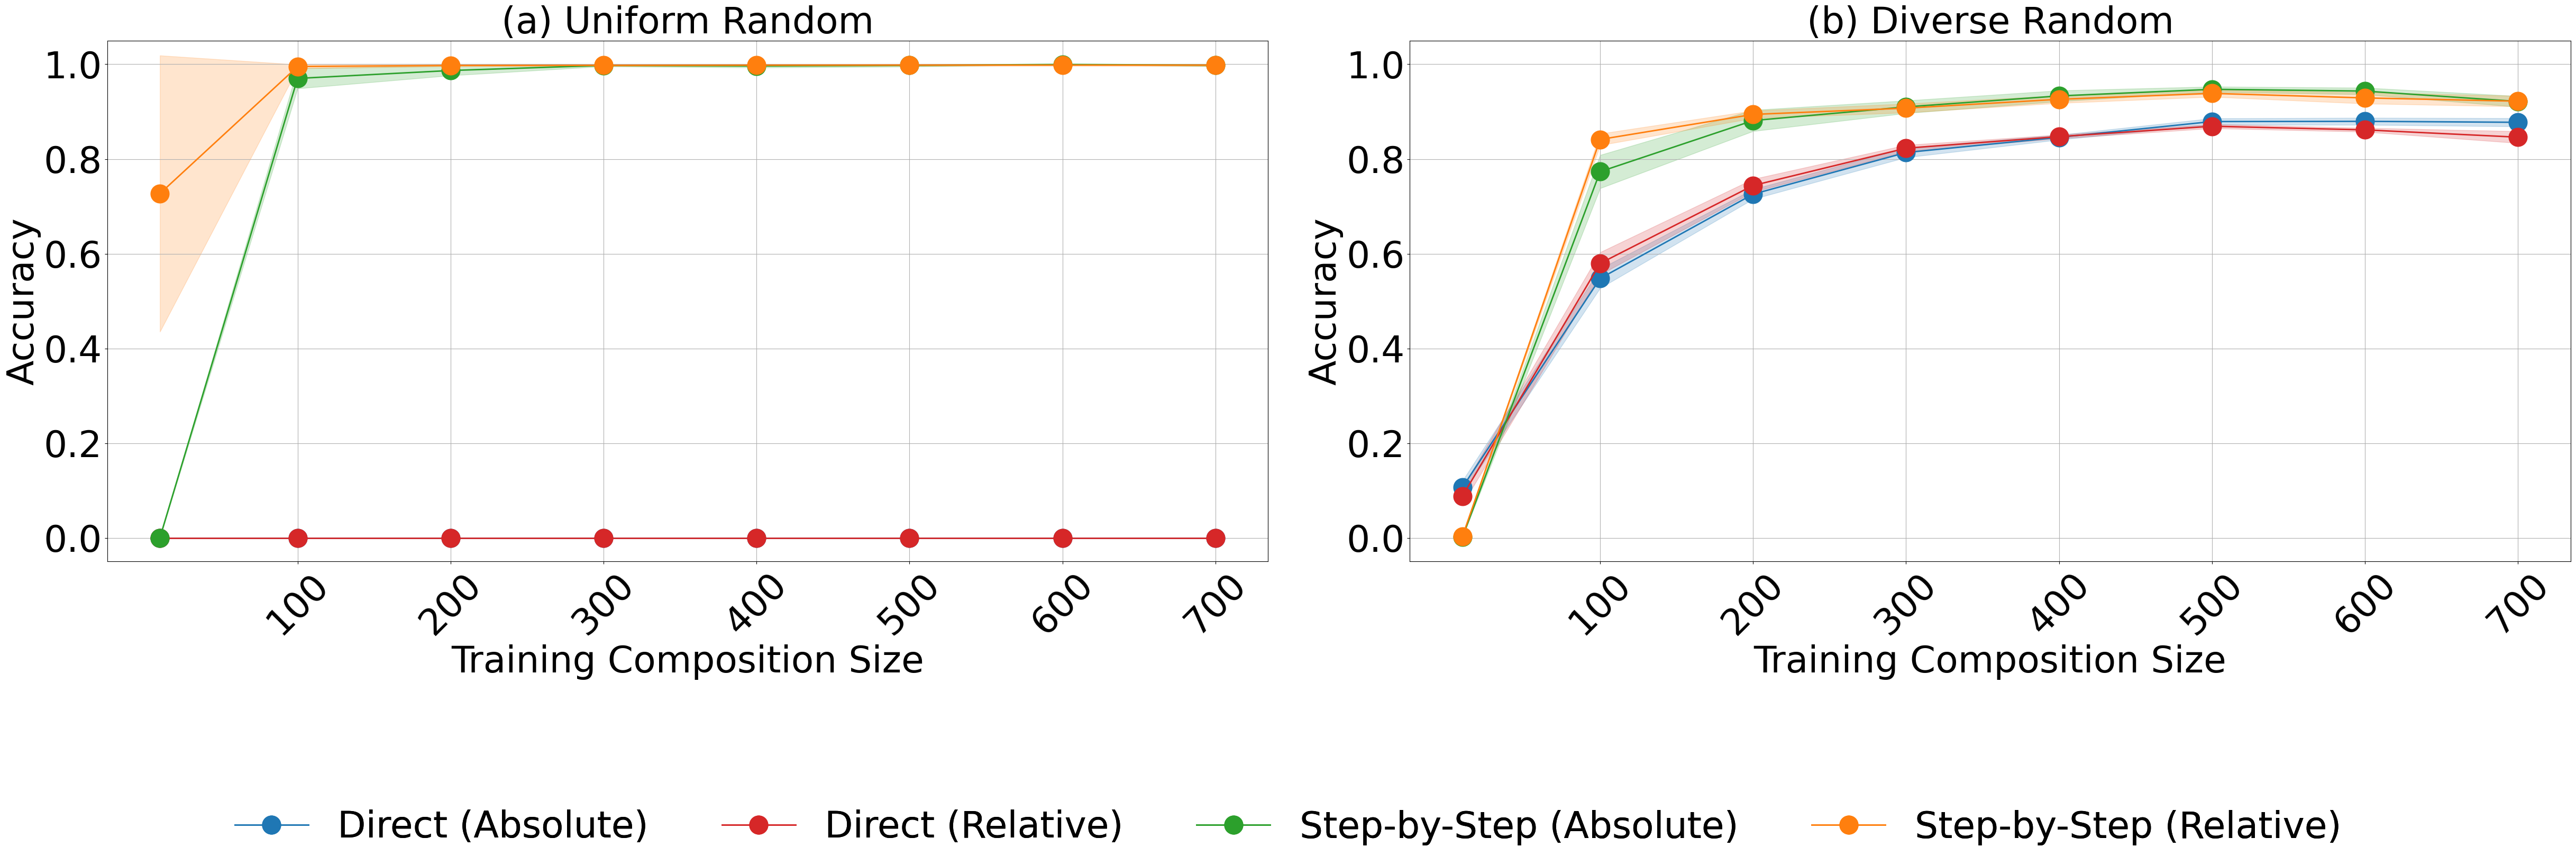

In [24]:
# plot line plot for with and without identity results side by side four plots with legend below 
from matplotlib import pyplot as plt
function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
num_permutations = [10, 100, 200, 300, 400, 500, 600, 700]
X = num_permutations

fig, axs = plt.subplots(1, 2, figsize=(50, 15))
# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
# have four subfigures with two plots each
colors = {
        "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
        "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
    }

for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[0].plot(X,results["uniform_random"]["test_mean_pts"][mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2, label=f"{mode_label} ({pos_label})")
        axs[0].fill_between(X, np.array(results["uniform_random"]["test_mean_pts"][mode][pos]["fixed"]) - np.array(results["uniform_random"]["test_std_pts"][mode][pos]["fixed"]), np.array(results["uniform_random"]["test_mean_pts"][mode][pos]["fixed"]) + np.array(results["uniform_random"]["test_std_pts"][mode][pos]["fixed"]), alpha=0.2, color=color)
        # have title below the plot
        axs[0].set_title(f"(a) Uniform Random", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[1].plot(X,results["diverse_random"]["test_mean_pts"][mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[1].fill_between(X, np.array(results["diverse_random"]["test_mean_pts"][mode][pos]["fixed"]) - np.array(results["diverse_random"]["test_std_pts"][mode][pos]["fixed"]), np.array(results["diverse_random"]["test_mean_pts"][mode][pos]["fixed"]) + np.array(results["diverse_random"]["test_std_pts"][mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[1].set_title(f"(b) Diverse Random", fontsize=font_size)



# for j, mode in enumerate(modes):
#     for k, pos in enumerate(pos_types):
#         print(mode, pos)
#         color = colors[mode + "_" + length][pos]
#         print(color)
#         pos_label = "Relative" if pos == "rel_global" else "Absolute"
#         mode_label = "Direct" if mode == "direct" else "Step-by-Step"
#         axs[2].plot(X,mean_optimal_coverage[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
#         axs[2].fill_between(X, np.array(mean_optimal_coverage[mode][pos]["fixed"]) - np.array(std_optimal_coverage[mode][pos]["fixed"]), np.array(mean_optimal_coverage[mode][pos]["fixed"]) + np.array(std_optimal_coverage[mode][pos]["fixed"]), alpha=0.2, color=color)
#         axs[2].set_title(f"(c) Optimal Coverage", fontsize=font_size)


# for j, mode in enumerate(modes):
#     for k, pos in enumerate(pos_types):
#         print(mode, pos)
#         color = colors[mode + "_" + length][pos]
#         print(color)
#         pos_label = "Relative" if pos == "rel_global" else "Absolute"
#         mode_label = "Direct" if mode == "direct" else "Step-by-Step"
#         axs[3].plot(X,train_3_uniform_results[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
#         axs[3].set_title(f"(d) Uniform (Train K=3)", fontsize=font_size)
    # set y-axis limit between 0 and 1
    axs[0].set_ylim(-0.05, 1.05)
    axs[1].set_ylim(-0.05, 1.05)
    # axs[2].set_ylim(-0.05, 1.05)
    # axs[3].set_ylim(-0.05, 1.05)
    # have x-axis label as Combination Size (K)
    axs[0].set_xlabel("Training Composition Size", fontsize=font_size)
    axs[1].set_xlabel("Training Composition Size", fontsize=font_size)
    # axs[2].set_xlabel("Training Permutation Size", fontsize=font_size)
    # axs[3].set_xlabel("Training Permutation Size", fontsize=font_size)
    # axs[3].set_xlabel("Evaluation K", fontsize=font_size)

    # have y-axis label as Accuracy
    axs[0].set_ylabel("Accuracy", fontsize=font_size)
    axs[1].set_ylabel("Accuracy", fontsize=font_size)
    # axs[2].set_ylabel("Accuracy", fontsize=font_size)
    # axs[3].set_ylabel("Accuracy", fontsize=font_size)

    # have legend below the four plots
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=font_size, bbox_to_anchor=(0.5, -0.15), frameon=False)
    
    # # just rotate 45 degrees
    # axs[0].set_xticks([10, 100, 200, 300, 400, 500, 600, 700])
    # axs[1].set_xticks([10, 100, 200, 300, 400, 500, 600, 700])
    # axs[2].set_xticks([10, 100, 200, 300, 400, 500, 600, 700])
    # show all ticks except the last one    
    axs[0].set_xticks(X[1:])
    axs[1].set_xticks(X[1:])
    # axs[2].set_xticks(X[1:])
    # axs[3].set_xticks(X[1:])
    axs[0].set_xticklabels(X[1:], rotation=45, fontsize=font_size)
    axs[1].set_xticklabels(X[1:], rotation=45, fontsize=font_size)
    # axs[2].set_xticklabels(X[1:], rotation=45, fontsize=font_size)
    # axs[3].set_xticklabels(X[1:], rotation=45, fontsize=font_size)
# have leg
    # have grid lines
    axs[0].grid(True)
    axs[1].grid(True)

# Save figure with legend below the plots, ensuring legend is included in the saved file
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.savefig("coverage_results.pdf", dpi=300, bbox_inches='tight')








In [9]:
results

{'uniform_random': {'train_mean_pts': {'direct': {'abs': {'fixed': [np.float32(0.9996799),
      np.float32(0.99718),
      np.float32(0.99922),
      np.float32(0.9989495),
      np.float32(0.9996599),
      np.float32(0.85028),
      np.float32(0.9996875),
      np.float32(0.9999592)]},
    'rel_global': {'fixed': [np.float32(0.99884),
      np.float32(0.99973994),
      np.float32(0.99974),
      np.float32(0.9995354),
      np.float32(0.99981993),
      np.float32(1.0),
      np.float32(0.999625),
      np.float32(0.99920404)]}},
   'step_by_step': {'abs': {'fixed': [np.float32(0.99983996),
      np.float32(0.99969995),
      np.float32(0.99981993),
      np.float32(0.999596),
      np.float32(0.99938),
      np.float32(0.99959993),
      np.float32(0.999625),
      np.float32(0.99924487)]},
    'rel_global': {'fixed': [np.float32(0.99723995),
      np.float32(0.9987399),
      np.float32(0.99874),
      np.float32(0.99830306),
      np.float32(0.99884),
      np.float32(0.9986599)

/scratch/login/ipykernel_112163/3818479232.py:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


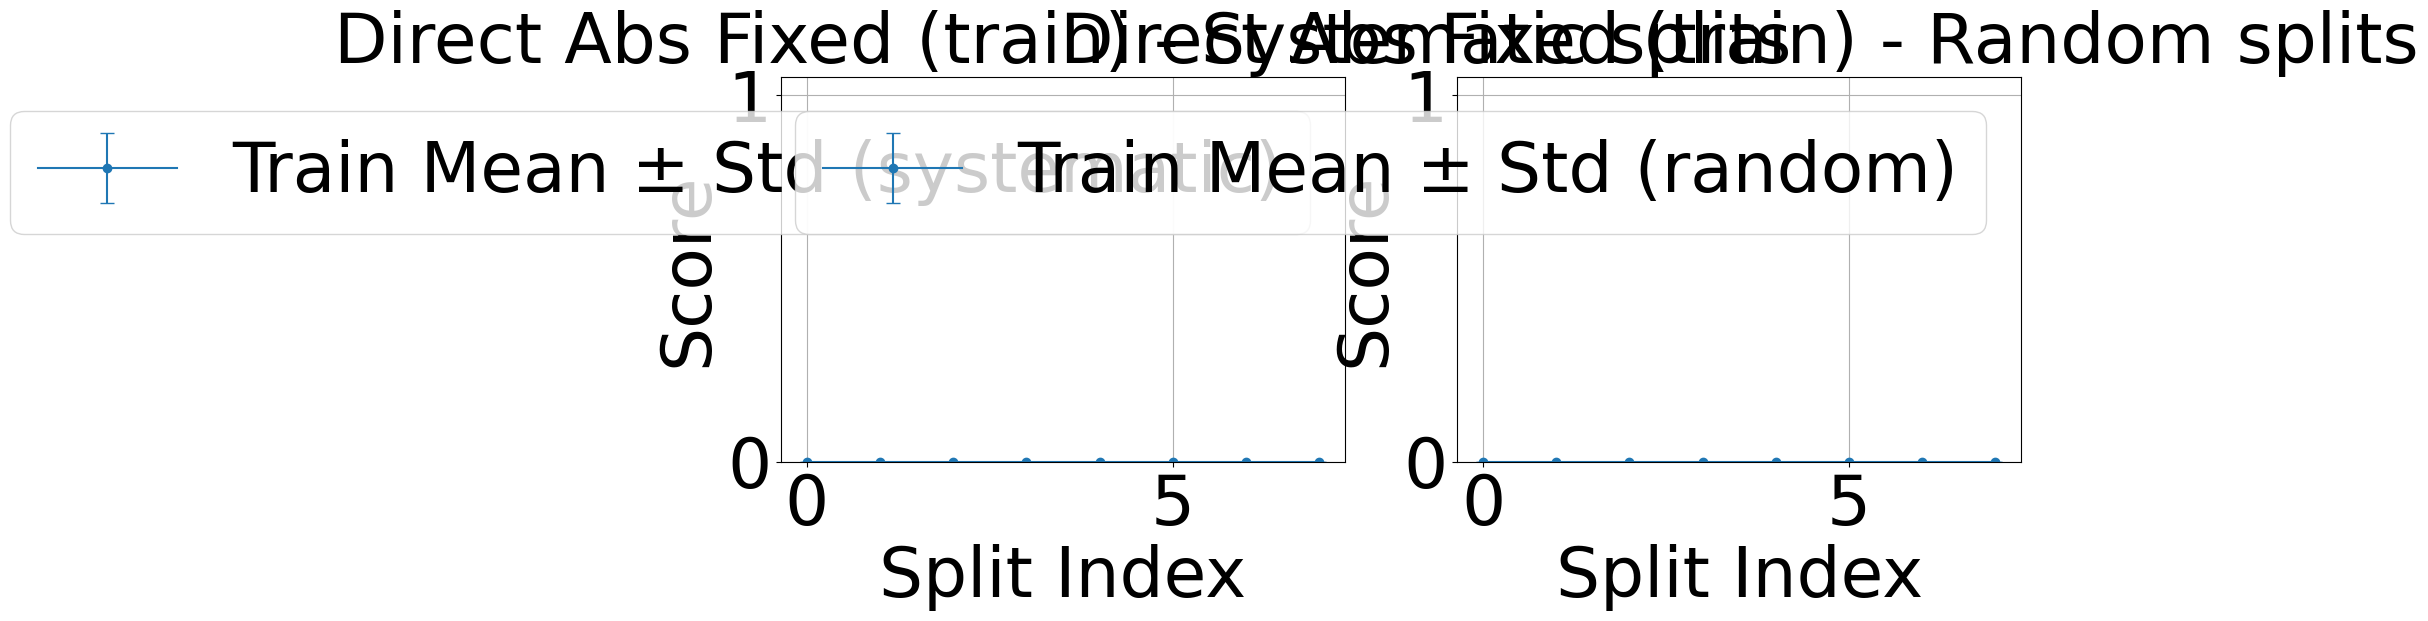

In [8]:
# plot results 
import matplotlib.pyplot as plt
import numpy as np

# Plot train/test mean points for each experiment, with std as error bars

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, (split_type, config_label) in enumerate([
    ("systematic", "uniform_systematic"),
    ("random", "uniform_random")
]):
    ax = axes[idx]
    mean = results[config_label]["test_mean_pts"]["direct"]["abs"]["fixed"]
    std = results[config_label]["test_std_pts"]["direct"]["abs"]["fixed"]
    x = np.arange(len(mean))
    ax.errorbar(x, mean, yerr=std, fmt='-o', capsize=5, label=f"Train Mean ± Std ({split_type})")
    ax.set_title(f"Direct Abs Fixed (train) - {split_type.capitalize()} splits")
    ax.set_xlabel("Split Index")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [5]:
from matplotlib import pyplot as plt
import pickle
import numpy as np

# Load metrics
METRICS_PATH = '/scratch4/workspace/ppruthi_umass_edu-CG/task_based_compositional_generalization'
with open(f'{METRICS_PATH}/systematic_metrics.pkl', 'rb') as f:
    systematic_metrics = pickle.load(f)
with open(f'{METRICS_PATH}/random_metrics.pkl', 'rb') as f:
    random_metrics = pickle.load(f)

def extract_metrics(metrics_dict, start_idx=2):
    """Extract and sort metrics from nested dictionary."""
    arr = metrics_dict['step_by_step']['uniform']['abs']
    
    # Extract data from start_idx onwards
    splits = [x[0] for x in arr[start_idx:]]
    divergence_values = [round(x[1], 2) for x in arr[start_idx:]]
    pairwise_values = [x[2] for x in arr[start_idx:]]
    position_values = [x[3] for x in arr[start_idx:]]
    
    # Sort by divergence values
    sorted_idx = np.argsort(divergence_values)
    divergence_values_sorted = [divergence_values[i] for i in sorted_idx]
    
    print(f"Sorted indices: {sorted_idx}")
    print(f"Divergence values: {divergence_values_sorted}")
    print(f"Sorted splits: {[splits[i] for i in sorted_idx]}")
    
    return {
        'splits': splits,
        'divergence': divergence_values_sorted,
        'pairwise': pairwise_values,
        'position': position_values,
        'sorted_idx': sorted_idx
    }

# Extract metrics
random_data = extract_metrics(random_metrics)
systematic_data = extract_metrics(systematic_metrics)
x_divergence_values_random = random_data["divergence"]
sorted_idx_random = random_data["sorted_idx"]
x_divergence_values_systematic = systematic_data["divergence"]
sorted_idx_systematic = systematic_data["sorted_idx"]

# Extract results for specified split
def get_split_data(results, split="test"):
    """Extract mean and std data for all result types."""
    result_types = ["uniform_random", "uniform_systematic", "diverse_random", "diverse_systematic"]
    
    data = {}
    for result_type in result_types:
        data[f"mean_{result_type}"] = results[result_type][f"{split}_mean_pts"]
        data[f"std_{result_type}"] = results[result_type][f"{split}_std_pts"]
    
    return data

split_data = get_split_data(results, split="test")

# Unpack for convenience
mean_uniform_random = split_data["mean_uniform_random"]
mean_uniform_systematic = split_data["mean_uniform_systematic"]
mean_diverse_random = split_data["mean_diverse_random"]
mean_diverse_systematic = split_data["mean_diverse_systematic"]

std_uniform_random = split_data["std_uniform_random"]
std_uniform_systematic = split_data["std_uniform_systematic"]
std_diverse_random = split_data["std_diverse_random"]
std_diverse_systematic = split_data["std_diverse_systematic"]

FileNotFoundError: [Errno 2] No such file or directory: '/scratch4/workspace/ppruthi_umass_edu-CG/task_based_compositional_generalization/systematic_metrics.pkl'

In [10]:
import numpy as np
from matplotlib import pyplot as plt

# Configuration
FUNCTION_TYPES = ["uniform", "diverse"]
MODES = ["direct", "step_by_step"]
POS_TYPES = ["abs", "rel_global"]
LENGTH = "fixed"
NUM_PERMUTATIONS = [10, 100, 200, 300, 400, 500, 600, 700]

# Color mapping
COLORS = {
    "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
    "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
}

# Label mappings
POS_LABELS = {"abs": "Absolute", "rel_global": "Relative"}
MODE_LABELS = {"direct": "Direct", "step_by_step": "Step-by-Step"}

# Plot configuration
PLOT_CONFIG = [
    {
        "index": 0,
        "title": "(a) Uniform (Random)",
        "mean_data": mean_uniform_random,
        "std_data": std_uniform_random,
        "x_values": x_divergence_values_random,
        "sorted_idx": sorted_idx_random,
        "show_legend": True
    },
    {
        "index": 1,
        "title": "(b) Uniform (Systematic)",
        "mean_data": mean_uniform_systematic,
        "std_data": std_uniform_systematic,
        "x_values": x_divergence_values_systematic,
        "sorted_idx": sorted_idx_systematic,
        "show_legend": False
    },
    {
        "index": 2,
        "title": "(c) Diverse (Random)",
        "mean_data": mean_diverse_random,
        "std_data": std_diverse_random,
        "x_values": x_divergence_values_random,
        "sorted_idx": sorted_idx_random,
        "show_legend": False
    },
    {
        "index": 3,
        "title": "(d) Diverse (Systematic)",
        "mean_data": mean_diverse_systematic,
        "std_data": std_diverse_systematic,
        "x_values": x_divergence_values_systematic,
        "sorted_idx": sorted_idx_systematic,
        "show_legend": False
    }
]

def plot_subplot(ax, config, modes, pos_types, colors, length, start_idx=0):
    """Plot data for a single subplot with error bands."""
    for mode in modes:
        for pos in pos_types:
            color = colors[f"{mode}_{length}"][pos]
            pos_label = POS_LABELS[pos]
            mode_label = MODE_LABELS[mode]
            
            mean_vals = config["mean_data"][mode][pos][length][start_idx-1:]
            sorted_mean = [mean_vals[i] for i in config["sorted_idx"]]
            
            std_vals = config["std_data"][mode][pos][length][start_idx-1:]
            sorted_std = [std_vals[i] for i in config["sorted_idx"]]
            
            label = f"{mode_label} ({pos_label})" if config["show_legend"] else None
            ax.plot(config["x_values"], sorted_mean, marker="o", linestyle="-", 
                   color=color, markersize=FONT_SIZE/2, linewidth=2, label=label)
            ax.fill_between(config["x_values"], 
                           np.array(sorted_mean) - np.array(sorted_std),
                           np.array(sorted_mean) + np.array(sorted_std),
                           alpha=0.15, color=color)  # Reduced alpha for clarity
    
    ax.set_title(config["title"], fontsize=FONT_SIZE)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("KL Divergence", fontsize=FONT_SIZE)
    ax.set_ylabel("Accuracy", fontsize=FONT_SIZE)
    
    # Show fewer ticks to reduce crowding
    if len(config["x_values"]) > 5:
        # Show first, last, and every other middle value
        tick_indices = [0] + list(range(1, len(config["x_values"])-1, 2)) + [len(config["x_values"])-1]
        selected_ticks = [config["x_values"][i] for i in tick_indices]
    else:
        selected_ticks = config["x_values"]
    
    ax.set_xticks(selected_ticks)
    ax.tick_params(axis='x', rotation=45, labelsize=FONT_SIZE*0.85)
    plt.setp(ax.xaxis.get_majorticklabels(), ha='right')
    ax.grid(True, alpha=0.25, linewidth=1)

# Create figure
fig, axs = plt.subplots(1, 4, figsize=(50, 15))

# Plot all subplots
for config in PLOT_CONFIG:
    plot_subplot(axs[config["index"]], config, MODES, POS_TYPES, COLORS, LENGTH, start_idx=2)

# Add legend below all plots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, 
          fontsize=FONT_SIZE, bbox_to_anchor=(0.5, -0.05), frameon=False)

# Save figure
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("systematic_permutation_evaluation.pdf", dpi=300, bbox_inches='tight')

NameError: name 'mean_uniform_random' is not defined

# Optimal Coverage Criterion

In [17]:
# plot line plot for with and without identity results side by side four plots with legend below 
from matplotlib import pyplot as plt

font_size = 50
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})

self_eval = True
random_coverage_cfg = {
    "modes": ["direct", "step_by_step"],
    "pos_types": ["abs", "rel_global"],
    "prompt_length": ["fixed"],
    "train_splits": ["permutationrandom_6_6", "permutationrandom_6_12", "permutationrandom_6_18", "permutationrandom_6_24", "permutationrandom_6_30", "permutationrandom_6_36"],
    "seeds": [0, 10, 20, 30, 40],
    "plot_direct_sbs": False,
    "function_type": "diverse",
    "task_max_length_flag": "fixed",
    "task_max_length": 6,
    "self_eval": True,
    "step_wise_mode": "individual"
}
random_coverage_cfg["nh_nl"] = "nh6_nl3"
random_coverage_cfg["evals"] = random_coverage_cfg["train_splits"] if random_coverage_cfg["self_eval"] else random_coverage_cfg["eval_splits"]
random_coverage_cfg["nalph"] = f"nalph_26_seqlen_6_fnlen_6_taskmaxlen_6"

randomrotated_coverage_cfg = random_coverage_cfg.copy()
randomrotated_coverage_cfg["function_type"] = "diverse"
randomrotated_coverage_cfg["task_max_length"] = 6
randomrotated_coverage_cfg["nalph"] = f"nalph_26_seqlen_6_fnlen_6_taskmaxlen_6"
randomrotated_coverage_cfg["train_splits"] = ["permutationrotated_6_6", 
"permutationrotated_6_12", 
"permutationrotated_6_18", 
"permutationrotated_6_24", 
"permutationrotated_6_30", 
"permutationrotated_6_36"]
randomrotated_coverage_cfg["evals"] = randomrotated_coverage_cfg["train_splits"] if randomrotated_coverage_cfg["self_eval"] else randomrotated_coverage_cfg["eval_splits"]




optimal_coverage_cfg = random_coverage_cfg.copy()
optimal_coverage_cfg["function_type"] = "diverse"
optimal_coverage_cfg["task_max_length"] = 6
optimal_coverage_cfg["nalph"] = f"nalph_26_seqlen_6_fnlen_6_taskmaxlen_6"
optimal_coverage_cfg["train_splits"] = ["permutationcoveragev1_6_6", 
"permutationcoveragev1_6_12", 
"permutationcoveragev1_6_18", 
"permutationcoveragev1_6_24", 
"permutationcoveragev1_6_30", 
"permutationcoveragev1_6_36"]
optimal_coverage_cfg["evals"] = optimal_coverage_cfg["train_splits"] if optimal_coverage_cfg["self_eval"] else optimal_coverage_cfg["eval_splits"]



In [12]:
results = {}
train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(random_coverage_cfg)
results["random_coverage"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}
train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(randomrotated_coverage_cfg)
results["randomrotated_coverage"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}
train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(optimal_coverage_cfg)
results["optimal_coverage"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}




['direct', 'step_by_step'] ['abs', 'rel_global'] ['fixed'] ['permutationrandom_6_6', 'permutationrandom_6_12', 'permutationrandom_6_18', 'permutationrandom_6_24', 'permutationrandom_6_30', 'permutationrandom_6_36'] ['permutationrandom_6_6', 'permutationrandom_6_12', 'permutationrandom_6_18', 'permutationrandom_6_24', 'permutationrandom_6_30', 'permutationrandom_6_36'] [0, 10, 20, 30, 40]
/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/models/eval/diverse/nalph_26_seqlen_6_fnlen_6_taskmaxlen_6/direct/fixed/model_permutationrandom_6_6/eval_permutationrandom_6_6/abs/nh6_nl3/seed_0/accs.pkl
direct abs fixed permutationrandom_6_6 permutationrandom_6_6 0
0.08793517
/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/models/eval/diverse/nalph_26_seqlen_6_fnlen_6_taskmaxlen_6/direct/fixed/model_permutationrandom_6_6/eval_permutationrandom_6_6/abs/nh6_nl3/seed_10/accs.pkl
direct abs fixed permutationrandom_6_6 permutationrandom_6_6 10
0.07162865
/project/pi

In [13]:
diverse_results = {}
train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(random_coverage_cfg)
diverse_results["random_coverage"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}
train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(randomrotated_coverage_cfg)
diverse_results["randomrotated_coverage"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}
train_mean_pts, train_std_pts, test_mean_pts, test_std_pts, _, _, _, _ = get_data(optimal_coverage_cfg)
diverse_results["optimal_coverage"] = {"train_mean_pts": train_mean_pts, "train_std_pts": train_std_pts, "test_mean_pts": test_mean_pts, "test_std_pts": test_std_pts}


['direct', 'step_by_step'] ['abs', 'rel_global'] ['fixed'] ['permutationrandom_6_6', 'permutationrandom_6_12', 'permutationrandom_6_18', 'permutationrandom_6_24', 'permutationrandom_6_30', 'permutationrandom_6_36'] ['permutationrandom_6_6', 'permutationrandom_6_12', 'permutationrandom_6_18', 'permutationrandom_6_24', 'permutationrandom_6_30', 'permutationrandom_6_36'] [0, 10, 20, 30, 40]
/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/models/eval/diverse/nalph_26_seqlen_6_fnlen_6_taskmaxlen_6/direct/fixed/model_permutationrandom_6_6/eval_permutationrandom_6_6/abs/nh6_nl3/seed_0/accs.pkl
direct abs fixed permutationrandom_6_6 permutationrandom_6_6 0
0.08793517
/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/models/eval/diverse/nalph_26_seqlen_6_fnlen_6_taskmaxlen_6/direct/fixed/model_permutationrandom_6_6/eval_permutationrandom_6_6/abs/nh6_nl3/seed_10/accs.pkl
direct abs fixed permutationrandom_6_6 permutationrandom_6_6 10
0.07162865
/project/pi

In [14]:
split = "test"
import numpy as np
mean_random_coverage = results["random_coverage"][f"{split}_mean_pts"]
mean_randomrotated_coverage = results["randomrotated_coverage"][f"{split}_mean_pts"]
mean_optimal_coverage = results["optimal_coverage"][f"{split}_mean_pts"]

std_random_coverage = results["random_coverage"][f"{split}_std_pts"]
std_randomrotated_coverage = results["randomrotated_coverage"][f"{split}_std_pts"]
std_optimal_coverage = results["optimal_coverage"][f"{split}_std_pts"]


In [ ]:
len(mean_optimal_coverage[mode][pos]["fixed"]), len(std_optimal_coverage[mode][pos]["fixed"])

NameError: name 'modes' is not defined

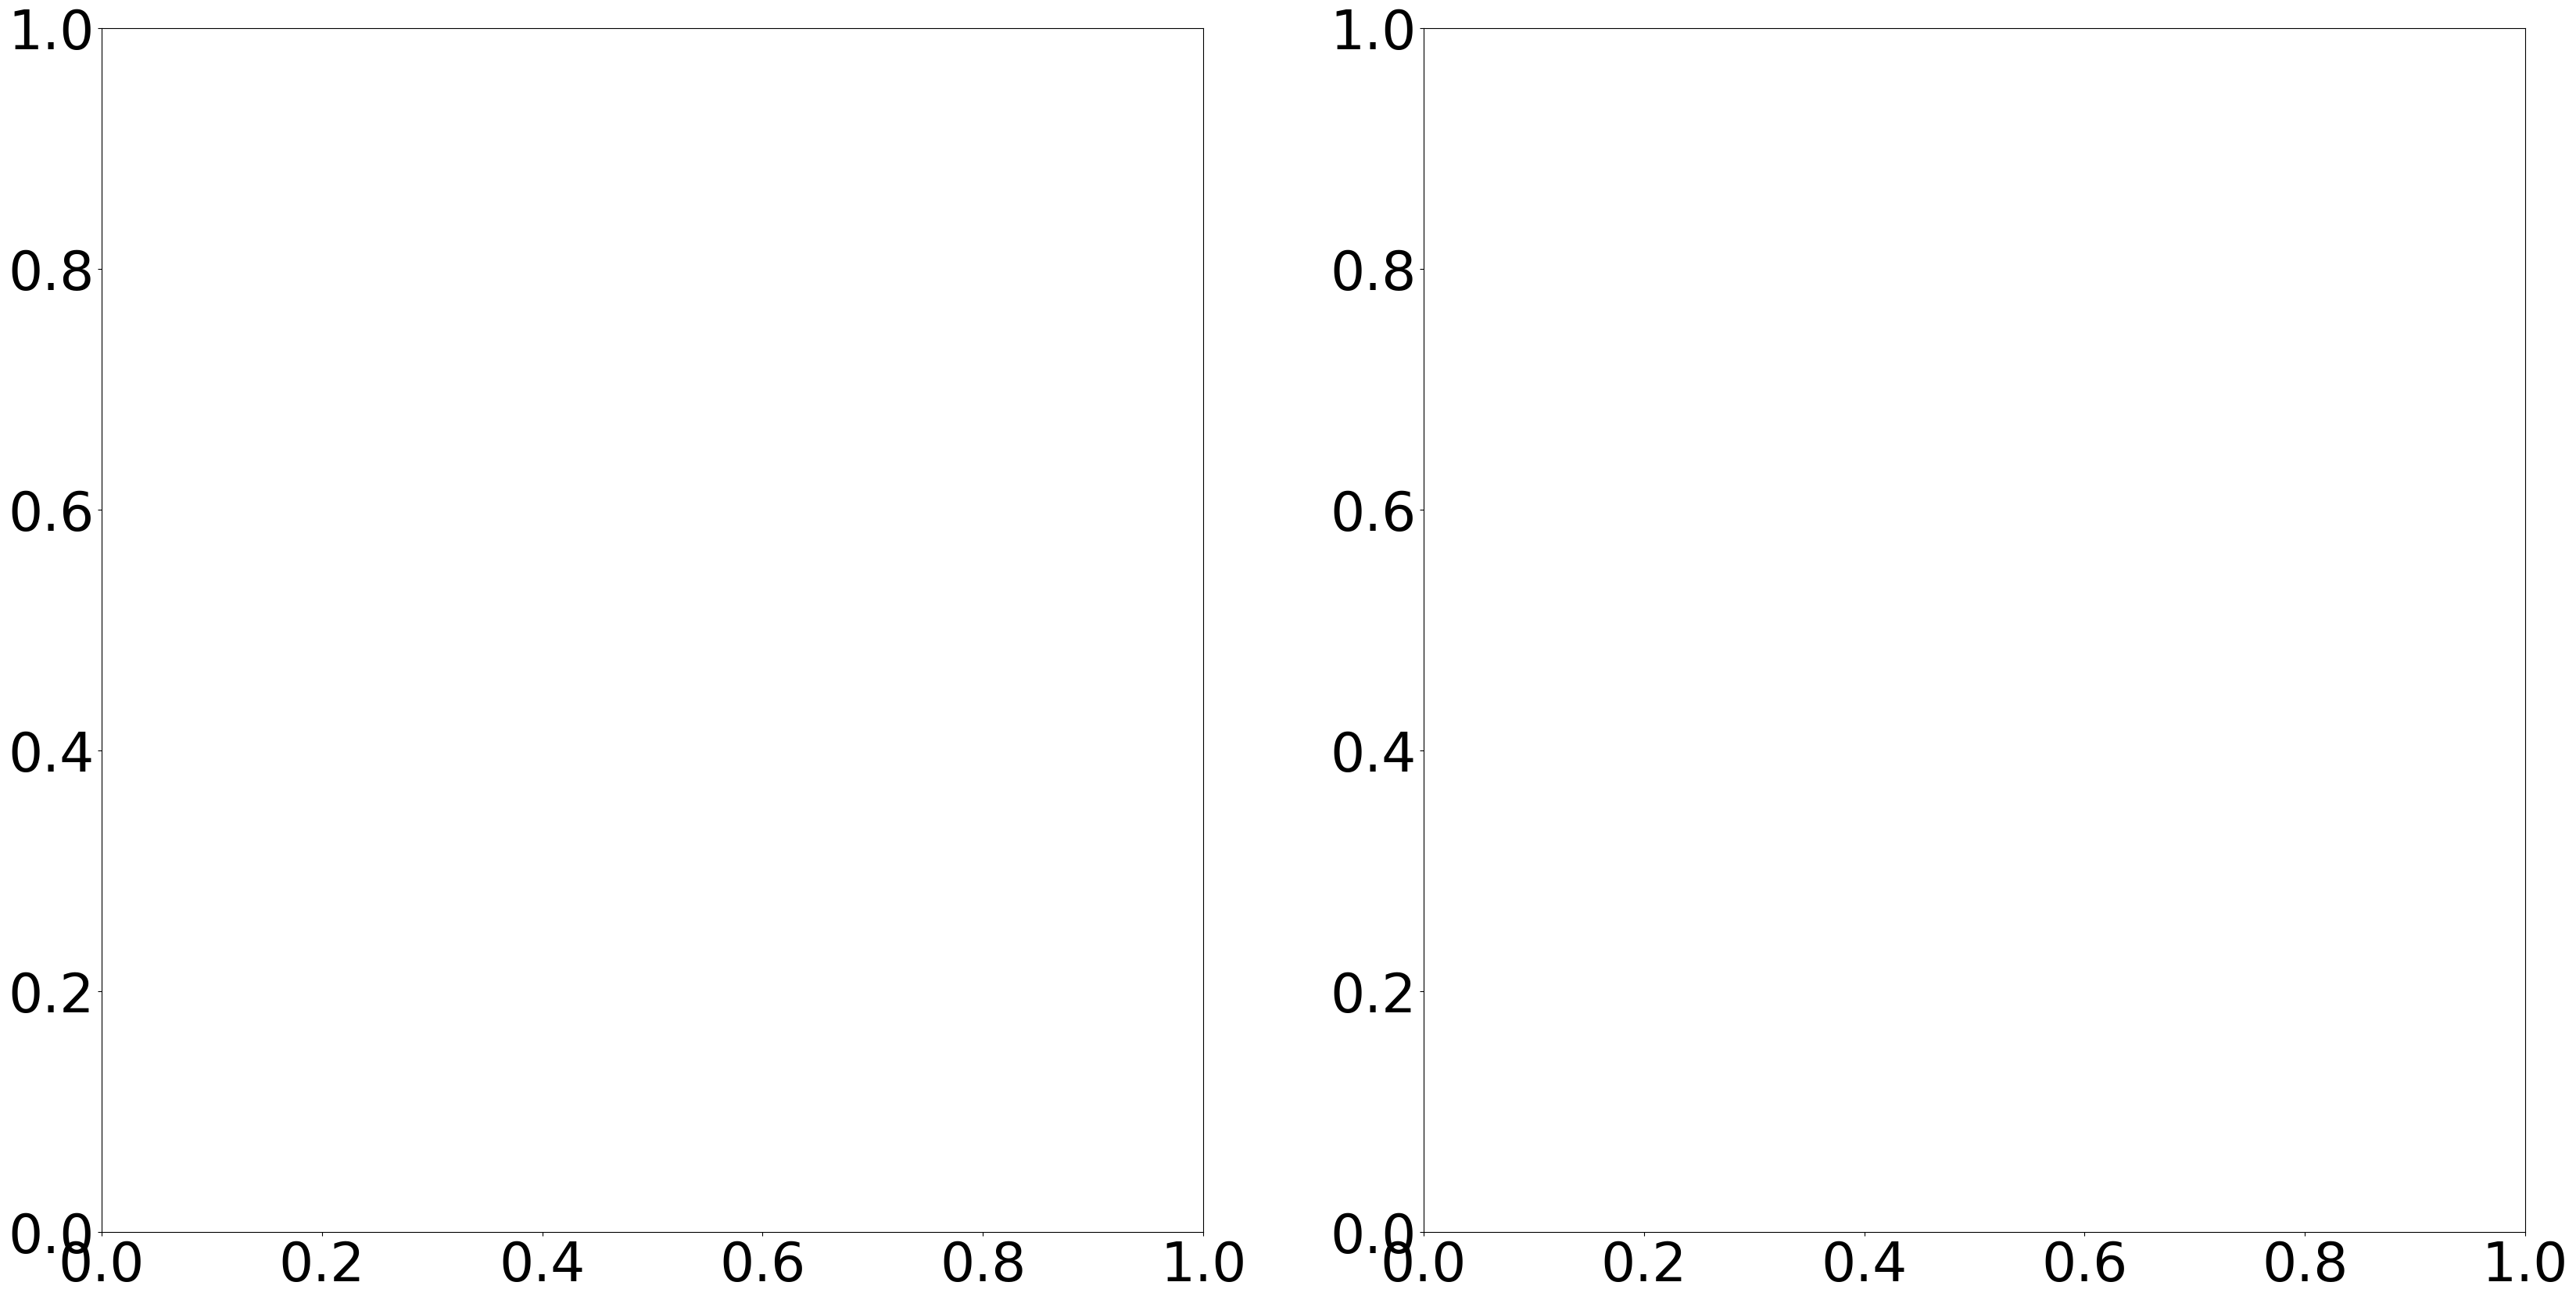

In [18]:
import numpy as np
X =[6, 12, 18, 24, 30, 36]
# Assuming you have these variables defined:
# modes, pos_types, colors, X, mean_optimal_coverage, std_optimal_coverage, length, font_size, axs
fig, axs = plt.subplots(1, 2, figsize=(40, 20))
# ... then run the bar plot code
# Calculate bar width and positions
n_groups = len(X)  # number of x-axis groups
n_bars_per_group = len(modes) * len(pos_types)
bar_width = 0.8 / n_bars_per_group  # total width of 0.8 divided by number of bars per group

# Create x positions for each group
x_positions = np.arange(n_groups)

# Counter for bar offset
bar_offset = 0

for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        
        # Create label for legend
        label = f"{mode_label} - {pos_label}"
        
        # Calculate x position for this set of bars
        x_pos = x_positions + (bar_offset - n_bars_per_group/2 + 0.5) * bar_width
        
        # Create bar plot
        bars = ax[0].bar(x_pos, 
                     mean_optimal_coverage[mode][pos]["fixed"], 
                     bar_width,
                     color=color, 
                     alpha=0.8,
                     label=label,
                     capsize=3)

                     
        
        # Add error bars
        ax[0].errorbar(x_pos, 
                   mean_optimal_coverage[mode][pos]["fixed"],
                   yerr=std_optimal_coverage[mode][pos]["fixed"],
                   fmt='none', 
                   color='black', 
                   alpha=0.7,
                   capsize=3,
                   capthick=1,
                   elinewidth=1)
        
        bar_offset += 1

# Set x-axis labels and title
ax.set_xticks(x_positions)
ax.set_xticklabels(["1-slot", "2-slot", "3-slot", "4-slot", "5-slot", "6-slot"], rotation=45, fontsize=font_size)  # Assuming X contains your x-axis labels
# have grid lines
ax.grid(True)
ax.set_title(f"Task Coverage Results (Uniform)", fontsize=font_size)
# ax.legend(fontsize=font_size-2)  # Add legend to distinguish different combinations
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=font_size, bbox_to_anchor=(0.5, -0.25), frameon=False)
    

['1%', '2%', '3%', '3%', '4%', '5%']
[6, 12, 18, 24, 30, 36]
direct abs
tab:blue
direct rel_global
tab:red
step_by_step abs
tab:green
step_by_step rel_global
tab:orange
{'direct_fixed': {'abs': 'tab:blue', 'rel_global': 'tab:red'}, 'step_by_step_fixed': {'abs': 'tab:green', 'rel_global': 'tab:orange'}}
direct abs
tab:blue
direct rel_global
tab:red
step_by_step abs
tab:green
step_by_step rel_global
tab:orange
{'direct_fixed': {'abs': 'tab:blue', 'rel_global': 'tab:red'}, 'step_by_step_fixed': {'abs': 'tab:green', 'rel_global': 'tab:orange'}}
direct abs
tab:blue
direct rel_global
tab:red
step_by_step abs
tab:green
step_by_step rel_global
tab:orange


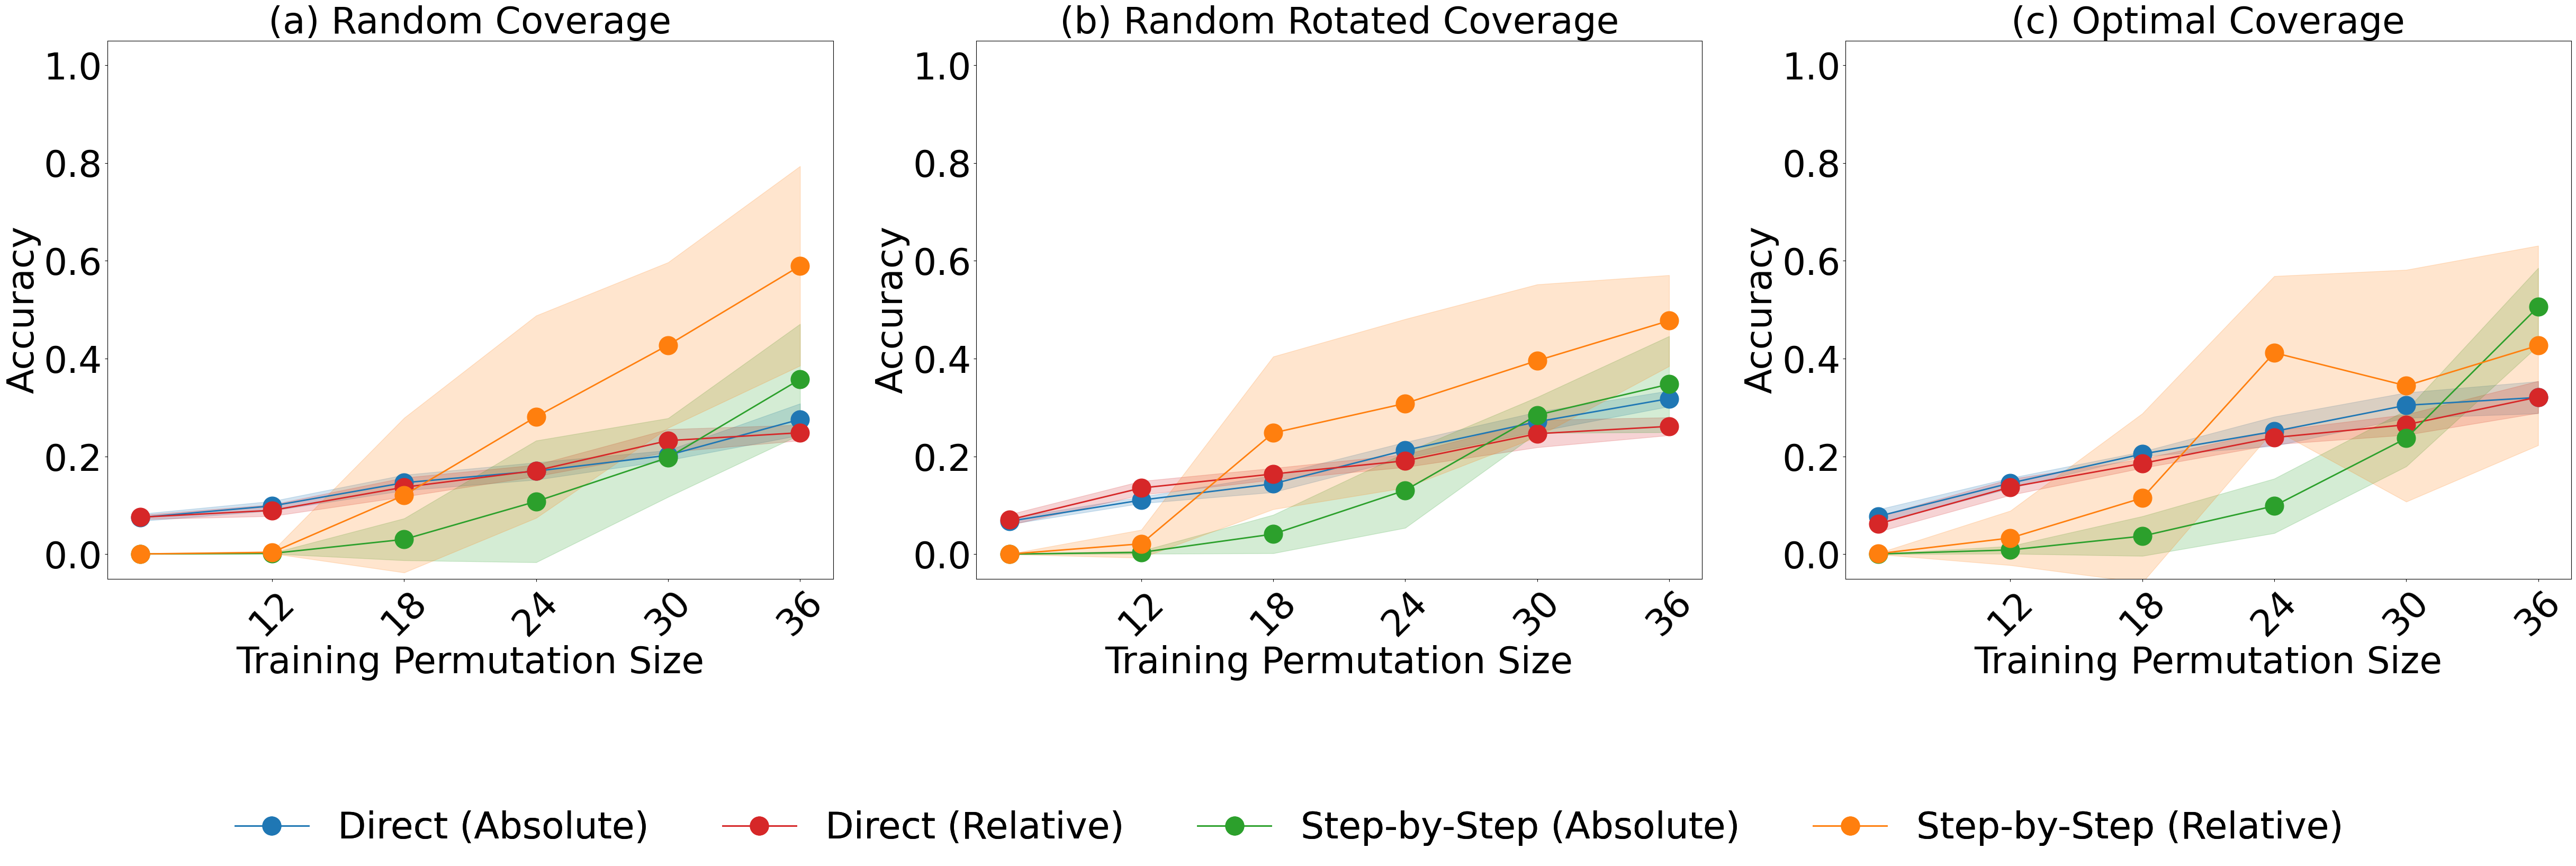

In [19]:

# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
num_permutations = [6, 12, 18, 24, 30, 36]
print([f"{int(round((x)/720, 2)*100)}%" for x in num_permutations])
X = num_permutations
print(X)
fig, axs = plt.subplots(1, 3, figsize=(50, 15))
# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
# have four subfigures with two plots each
colors = {
        "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
        "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
    }

for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[0].plot(X,mean_random_coverage[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2, label=f"{mode_label} ({pos_label})")
        axs[0].fill_between(X, np.array(mean_random_coverage[mode][pos]["fixed"]) - np.array(std_random_coverage[mode][pos]["fixed"]), np.array(mean_random_coverage[mode][pos]["fixed"]) + np.array(std_random_coverage[mode][pos]["fixed"]), alpha=0.2, color=color)
        # have title below the plot
        axs[0].set_title(f"(a) Random Coverage", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[1].plot(X,mean_randomrotated_coverage[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[1].fill_between(X, np.array(mean_randomrotated_coverage[mode][pos]["fixed"]) - np.array(std_randomrotated_coverage[mode][pos]["fixed"]), np.array(mean_randomrotated_coverage[mode][pos]["fixed"]) + np.array(std_randomrotated_coverage[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[1].set_title(f"(b) Random Rotated Coverage", fontsize=font_size)

print(colors)

for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        axs[2].plot(X,mean_optimal_coverage[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
        axs[2].fill_between(X, np.array(mean_optimal_coverage[mode][pos]["fixed"]) - np.array(std_optimal_coverage[mode][pos]["fixed"]), np.array(mean_optimal_coverage[mode][pos]["fixed"]) + np.array(std_optimal_coverage[mode][pos]["fixed"]), alpha=0.2, color=color)
        axs[2].set_title(f"(c) Optimal Coverage", fontsize=font_size)


# for j, mode in enumerate(modes):
#     for k, pos in enumerate(pos_types):
#         print(mode, pos)
#         color = colors[mode + "_" + length][pos]
#         print(color)
#         pos_label = "Relative" if pos == "rel_global" else "Absolute"
#         mode_label = "Direct" if mode == "direct" else "Step-by-Step"
#         axs[3].plot(X,train_3_uniform_results[mode][pos]["fixed"], marker="o", linestyle="-", color=color, markersize=font_size/2, linewidth=2)
#         axs[3].set_title(f"(d) Uniform (Train K=3)", fontsize=font_size)
    # set y-axis limit between 0 and 1
    axs[0].set_ylim(-0.05, 1.05)
    axs[1].set_ylim(-0.05, 1.05)
    axs[2].set_ylim(-0.05, 1.05)
    # axs[3].set_ylim(-0.05, 1.05)
    # have x-axis label as Combination Size (K)
    axs[0].set_xlabel("Training Permutation Size", fontsize=font_size)
    axs[1].set_xlabel("Training Permutation Size", fontsize=font_size)
    axs[2].set_xlabel("Training Permutation Size", fontsize=font_size)
    # axs[3].set_xlabel("Training Permutation Size", fontsize=font_size)
    # axs[3].set_xlabel("Evaluation K", fontsize=font_size)

    # have y-axis label as Accuracy
    axs[0].set_ylabel("Accuracy", fontsize=font_size)
    axs[1].set_ylabel("Accuracy", fontsize=font_size)
    axs[2].set_ylabel("Accuracy", fontsize=font_size)
    # axs[3].set_ylabel("Accuracy", fontsize=font_size)

    # have legend below the four plots
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=font_size, bbox_to_anchor=(0.5, -0.15), frameon=False)
    
    # # just rotate 45 degrees
    # axs[0].set_xticks([10, 100, 200, 300, 400, 500, 600, 700])
    # axs[1].set_xticks([10, 100, 200, 300, 400, 500, 600, 700])
    # axs[2].set_xticks([10, 100, 200, 300, 400, 500, 600, 700])
    # show all ticks except the last one    
    axs[0].set_xticks(X[1:])
    axs[1].set_xticks(X[1:])
    axs[2].set_xticks(X[1:])
    # axs[3].set_xticks(X[1:])
    axs[0].set_xticklabels(X[1:], rotation=45, fontsize=font_size)
    axs[1].set_xticklabels(X[1:], rotation=45, fontsize=font_size)
    axs[2].set_xticklabels(X[1:], rotation=45, fontsize=font_size)
    # axs[3].set_xticklabels(X[1:], rotation=45, fontsize=font_size)
# have leg
        

# Save figure with legend below the plots, ensuring legend is included in the saved file
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.savefig("coverage_results.pdf", dpi=300, bbox_inches='tight')








In [ ]:
# plot line plot for step_by_step, rel_global only - different colors for coverage types
function_types = ["uniform"]
modes = ["step_by_step"]
pos_types = ["rel_global"]
length = "fixed"
num_permutations = [6, 12, 18, 24, 30, 36]
print([f"{int(round((x)/720, 2)*100)}%" for x in num_permutations])
X = num_permutations
print(X)

# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(30, 15))

# Simplified colors - one for each coverage type
coverage_colors = {
    "random": "tab:blue",
    "randomrotated": "tab:red", 
    "optimal": "tab:green"
}

# Define line styles for different coverage types
line_styles = {
    "random": "-",
    "randomrotated": "-",
    "optimal": "-"
}

# Define markers for different coverage types
markers = {
    "random": "o",
    "randomrotated": "s",
    "optimal": "^"
}

# Plot all coverage types on single plot - only step_by_step, rel_global
for coverage_type, coverage_data in [("random", mean_random_coverage), 
                                     ("randomrotated", mean_randomrotated_coverage), 
                                     ("optimal", mean_optimal_coverage)]:
    
    # Get corresponding std data
    if coverage_type == "random":
        std_data = std_random_coverage
    elif coverage_type == "randomrotated":
        std_data = std_randomrotated_coverage
    else:  # optimal
        std_data = std_optimal_coverage
    
    # Only process step_by_step and rel_global
    mode = "step_by_step"
    pos = "rel_global"
    
    print(f"{coverage_type}: {mode}, {pos}")
    color = coverage_colors[coverage_type]
    print(color)
    
    # Simplified label - just coverage type
    coverage_label = coverage_type.replace("randomrotated", "Random Rotated").replace("random", "Random").replace("optimal", "Optimal")
    label = f"{coverage_label}"
    
    ax.plot(X, coverage_data[mode][pos]["fixed"], 
           marker=markers[coverage_type], 
           linestyle=line_styles[coverage_type], 
           color=color, 
           markersize=font_size/2, 
           linewidth=2, 
           label=label)
    
    ax.fill_between(X, 
                  np.array(coverage_data[mode][pos]["fixed"]) - np.array(std_data[mode][pos]["fixed"]), 
                  np.array(coverage_data[mode][pos]["fixed"]) + np.array(std_data[mode][pos]["fixed"]), 
                  alpha=0.2, 
                  color=color)

# Set plot properties
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Training Permutation Size", fontsize=font_size)
ax.set_ylabel("Accuracy", fontsize=font_size)
ax.set_title("Coverage Results Comparison (Step-by-Step, Relative Global)", fontsize=font_size)

# Set x-axis ticks
ax.set_xticks(X[1:])
ax.set_xticklabels(X[1:], rotation=45, fontsize=font_size)

# Add legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.5), fontsize=font_size, frameon=False, ncol=3)

# Save figure
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.savefig("coverage_results_combined_diverse.pdf", dpi=300, bbox_inches='tight')

# Systematically leaking the equivalence class


In [ ]:
from matplotlib import pyplot as plt
trains = ["equivalence_6_576_1", "equivalence_6_576_25", "equivalence_6_576_49", "equivalence_6_576_73", "equivalence_6_576_97", "equivalence_6_576_121", "equivalence_6_576_144"]
font_size = 30
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})
plt.figure(figsize=(20, 15))
direct_results ={'direct': {'abs': {'fixed': [0.0069444440305233, 0.17217811942100525, 0.32297176122665405, 0.4248236119747162, 0.6001983880996704, 0.5865299701690674, 0.5830026268959045]}, 'rel_global': {'fixed': [0.0065035270527005196, 0.17294973134994507, 0.33487653732299805, 0.4971340298652649, 0.6464946866035461, 0.8141534328460693, 0.962522029876709]}}}

sizes = [int(t.split("_")[3]) for t in trains]
train_perm_size = [int(t.split("_")[2]) for t in trains]
# unique train permutations
unique_train_perm_size = list(set(train_perm_size))[0]
unique_test_perm_size = 720 - unique_train_perm_size
total_test_perm_size = unique_test_perm_size * 7

num_combinations_leaked = [7*size for size in sizes]
predicted_accuracy = [num/(total_test_perm_size) for num in num_combinations_leaked]
print(predicted_accuracy)
predicted_accuracy = [round(num, 2) for num in predicted_accuracy]
sizes = [round(size/unique_test_perm_size, 2) for size in sizes]
# plot predicted accuracy
plt.plot(predicted_accuracy, marker="o", linestyle="-", color="black", label="Predicted Accuracy", markersize=font_size)
plt.plot(direct_results['direct']['abs']['fixed'], marker="o", linestyle="-", color="tab:blue", label="Direct (Absolute)", markersize=font_size)
plt.plot(direct_results['direct']['rel_global']['fixed'], marker="o", linestyle="-", color="tab:red", label="Direct (Relative)", markersize=font_size)
# plt.xticks(range(len(sizes)), sizes*100, fontsize=font_size)
# plot percentage on x axis 
plt.xticks(range(len(sizes)), [f"{int(size*100)}%" for size in sizes], fontsize=font_size)
plt.xlabel("Identity-based Equivalence Class Leakage (%)", fontsize=font_size)
# include legend for predicted accuracy
plt.legend()
plt.tight_layout()
plt.savefig("equivalence_class_leakage.pdf", dpi=300, bbox_inches='tight')




In [ ]:
# Combined plot with all three coverage types in one plot
function_types = ["uniform", "diverse"]
modes = ["direct", "step_by_step"]
pos_types = ["abs", "rel_global"]
length = "fixed"
num_permutations = [6, 12, 18, 24, 30, 36]
print([f"{int(round((x)/720, 2)*100)}%" for x in num_permutations])
X = num_permutations
print(X)

# Create a single plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Define colors for different coverage types
coverage_colors = {
    "random": {"direct": {"abs": "tab:blue", "rel_global": "tab:red"},
               "step_by_step": {"abs": "tab:green", "rel_global": "tab:orange"}},
    "randomrotated": {"direct": {"abs": "tab:purple", "rel_global": "tab:brown"},
                      "step_by_step": {"abs": "tab:pink", "rel_global": "tab:gray"}},
    "optimal": {"direct": {"abs": "tab:cyan", "rel_global": "tab:olive"},
                "step_by_step": {"abs": "tab:yellow", "rel_global": "tab:black"}}
}

# Plot Random Coverage
for mode in modes:
    for pos in pos_types:
        color = coverage_colors["random"][mode][pos]
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        label = f"Random - {mode_label} ({pos_label})"
        ax.plot(X, mean_random_coverage[mode][pos]["fixed"], 
                marker="o", linestyle="-", color=color, markersize=6, linewidth=2, label=label)
        ax.fill_between(X, 
                        np.array(mean_random_coverage[mode][pos]["fixed"]) - np.array(std_random_coverage[mode][pos]["fixed"]), 
                        np.array(mean_random_coverage[mode][pos]["fixed"]) + np.array(std_random_coverage[mode][pos]["fixed"]), 
                        alpha=0.2, color=color)

# Plot Random Rotated Coverage
for mode in modes:
    for pos in pos_types:
        color = coverage_colors["randomrotated"][mode][pos]
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        label = f"Random Rotated - {mode_label} ({pos_label})"
        ax.plot(X, mean_randomrotated_coverage[mode][pos]["fixed"], 
                marker="s", linestyle="--", color=color, markersize=6, linewidth=2, label=label)
        ax.fill_between(X, 
                        np.array(mean_randomrotated_coverage[mode][pos]["fixed"]) - np.array(std_randomrotated_coverage[mode][pos]["fixed"]), 
                        np.array(mean_randomrotated_coverage[mode][pos]["fixed"]) + np.array(std_randomrotated_coverage[mode][pos]["fixed"]), 
                        alpha=0.2, color=color)

# Plot Optimal Coverage
for mode in modes:
    for pos in pos_types:
        color = coverage_colors["optimal"][mode][pos]
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        label = f"Optimal - {mode_label} ({pos_label})"
        ax.plot(X, mean_optimal_coverage[mode][pos]["fixed"], 
                marker="^", linestyle=":", color=color, markersize=6, linewidth=2, label=label)
        ax.fill_between(X, 
                        np.array(mean_optimal_coverage[mode][pos]["fixed"]) - np.array(std_optimal_coverage[mode][pos]["fixed"]), 
                        np.array(mean_optimal_coverage[mode][pos]["fixed"]) + np.array(std_optimal_coverage[mode][pos]["fixed"]), 
                        alpha=0.2, color=color)

# Set plot properties
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Training Permutation Size", fontsize=font_size)
ax.set_ylabel("Accuracy", fontsize=font_size)
ax.set_title("Coverage Results Comparison", fontsize=font_size+2)

# Set x-axis ticks
ax.set_xticks(X[1:])
ax.set_xticklabels(X[1:], rotation=45, fontsize=font_size)

# Add legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=font_size-2)

# Add grid for better readability
ax.grid(True, alpha=0.3)

# Save figure
plt.tight_layout()
plt.savefig("combined_coverage_results.pdf", dpi=300, bbox_inches='tight')
plt.show()
